<a href="https://colab.research.google.com/github/Ali-sobhy1/Andys_YouTube_Notebooks/blob/main/Estimation_of_Drilling_Rate_of_Penetration_depending_on_MWD_2332026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Estimation of Rate of Penetration depending on MWD log.

In the drilling industry, the rate of penetration (ROP), also known as penetration rate or drill rate, is the speed at which a drill bit breaks the rock under it to deepen the borehole. It is normally measured in feet per minute or meters per hour, but sometimes it is expressed in minutes per foot.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


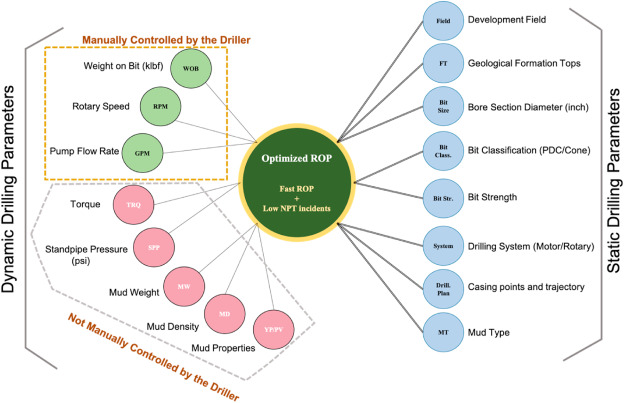

"Good morning, everyone. Today, we are moving beyond traditional 'drill-by-feel' methods. We are looking at a digital twin of our drilling operation—a dataset captured from the surface and downhole sensors of an active rig. Our mission is simple but critical: Maximize the Rate of Penetration (ROP) while maintaining borehole integrity."
"Our primary focus in this analysis is to decode the Mechanical Specific Energy (MSE) trends. MSE is the energy required to remove a unit volume of rock; when MSE is low, we are drilling efficiently. When it spikes, we are wasting energy on vibrations, bit balling, or friction. By the end of this notebook, we will have identified the best parameters that allows us to drill the fastest without damaging our equipment."
________________________________________
The Dataset: Our Digital Drilling Record
"To get there, we are analyzing eight critical parameters. Each tells a specific story about what is happening thousands of feet below the surface:"
•	Hole Depth: Our vertical context. It dictates the compaction and strength of the rock we are fighting.
•	Hook Load: This allows us to monitor the weight of the drill string and ensures we aren't stuck or experiencing excessive drag.
•	Rotary RPM & Torque: The 'twist' and 'speed.' This is the rotational energy we provide, and the torque is the rock's resistance to that energy.
•	Weight on Bit (WOB): The downward force. Too little and we don't 'bite' the rock; too much and we risk dysfunction.
•	Differential Pressure: Our window into the downhole motor's performance and the cleaning efficiency of our drilling fluids.
•	Gamma at Bit: Our geological compass. It tells us the lithology (shale vs. sandstone) so we can adjust our parameters as the formation changes.
•	Rate Of Penetration (ROP): Our target variable. The speed at which we progress.
________________________________________
The Methodology: From Raw Noise to Predictive Power
"We aren't just plugging numbers into a formula. Our workflow follows a rigorous engineering pipeline:"
1.	Data Hygiene & Cleaning: We start by stripping away the 'noise.' We filter out 'off-bottom' data (where the bit isn't touching the rock) and handle sensor spikes to ensure our model learns from real drilling, not sensor errors.
2.	Feature Scaling: Since 'Hole Depth' is measured in thousands and 'RPM' in hundreds, we normalize our features. This ensures that the Machine Learning model treats each physical input with the correct mathematical weight.
3.	Regression Modeling: Finally, we implement advanced regression algorithms. These models learn the non-linear relationship between our inputs and ROP, allowing us to simulate 'What If' scenarios to predict the fastest way to the target depth."


In [ ]:
#Import Libraries
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import chi2 , f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV
import pathlib
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


SimpleImputer (from sklearn.impute): Used for handling missing values in a dataset by replacing them with a placeholder value (e.g., mean, median, most frequent). It's crucial for preparing data for models that cannot handle missing entries.
numpy: A fundamental package for numerical computation in Python. It provides powerful array objects and tools for working with them, essential for mathematical operations in data science.
pandas: A library providing high-performance, easy-to-use data structures (like DataFrames) and data analysis tools. It's indispensable for data loading, cleaning, manipulation, and exploration.
seaborn: A Python data visualization library based on Matplotlib, providing a high-level interface for drawing attractive and informative statistical graphics. It simplifies complex plots for data exploration.
matplotlib.pyplot: A plotting library used for creating static, interactive, and animated visualizations in Python. It provides fine-grained control over plots and is often used alongside Seaborn.
SelectPercentile (from sklearn.feature_selection): A feature selection method that removes all but the highest scoring percentile of features. It helps in reducing dimensionality and improving model performance by selecting the most relevant features.
chi2 and f_classif (from sklearn.feature_selection): Statistical tests used for feature selection, particularly for classification tasks. chi2 is used for non-negative features (e.g., counts), and f_classif (ANOVA F-value) is for numerical input and categorical output.
StandardScaler (from sklearn.preprocessing): Standardizes features by removing the mean and scaling to unit variance. This is important for many machine learning algorithms that perform better when features are on a similar scale.
train_test_split (from sklearn.model_selection): A function for splitting datasets into training and testing subsets. This is fundamental for evaluating the generalization performance of a machine learning model.
LinearRegression (from sklearn.linear_model): Implements ordinary least squares Linear Regression. It's a basic but powerful algorithm for modeling the relationship between a dependent variable and one or more independent variables.
SGDRegressor (from sklearn.linear_model): Implements linear models with stochastic gradient descent (SGD) training. It's efficient for large datasets as it updates model parameters iteratively.
Lasso (from sklearn.linear_model): A linear regression model that uses L1 regularization. It's useful for feature selection as it can shrink some coefficients to zero, effectively removing some features from the model.
RandomForestRegressor (from sklearn.ensemble): An ensemble learning method for regression that constructs multiple decision trees during training and outputs the average prediction of the individual trees. It's known for its high accuracy and robustness.
SVR (Support Vector Regression, from sklearn.svm): A type of Support Vector Machine that performs regression. It works by finding a hyperplane that best fits the data points within a certain margin of error.
MLPRegressor (Multi-layer Perceptron Regressor, from sklearn.neural_network): A neural network model for regression tasks. It can learn complex non-linear relationships in the data through multiple layers of interconnected neurons.
mean_absolute_error, mean_squared_error, median_absolute_error (from sklearn.metrics): These are common metrics used to evaluate the performance of regression models. They quantify the difference between predicted and actual values.
cross_val_predict (from sklearn.model_selection): Generates cross-validated predictions for each data point in the input. This is useful for getting predictions on unseen data while still using all data for evaluation.
GridSearchCV (from sklearn.model_selection): Implements an exhaustive search over specified parameter values for an estimator. It's used for systematically tuning hyperparameters to find the best performing model configuration.
pathlib: A module for object-oriented filesystem paths. It provides an intuitive way to interact with file paths, making file operations more readable and robust.
tensorflow: An open-source machine learning framework developed by Google. It's a comprehensive ecosystem of tools, libraries, and community resources that lets researchers push the state-of-the-art in ML and developers easily build and deploy ML-powered applications.
tensorflow.keras: A high-level API for building and training deep learning models. It provides an easy-to-use interface for designing neural networks within TensorFlow.
tensorflow.keras.layers: The building blocks for neural networks in Keras. It includes various types of layers (e.g., Dense, Conv2D, MaxPooling2D) that can be stacked to create deep learning architectures.

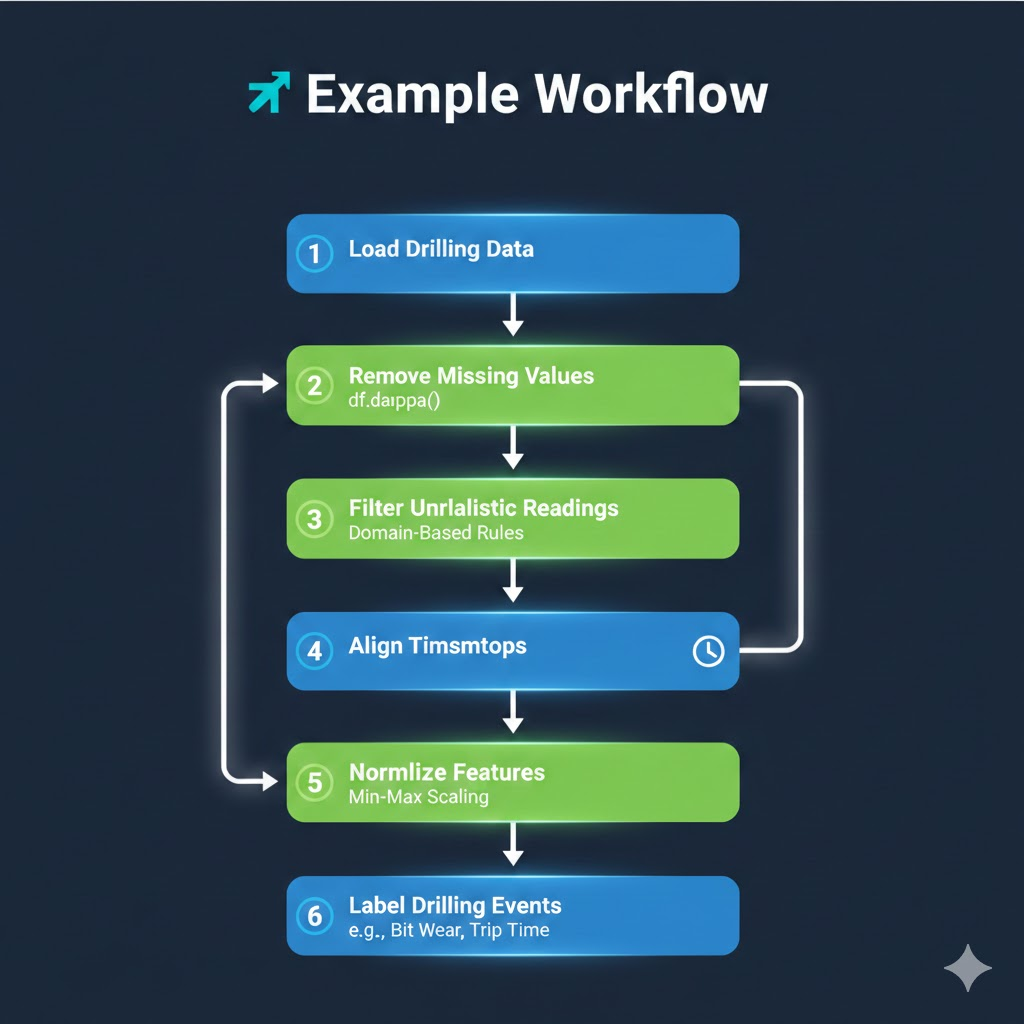

I have a drilling dataset with columns: 'Hole Depth', 'Hook Load', 'Rotary RPM', 'Rotary Torque', 'Weight on Bit', 'Differential Pressure', 'Gamma at Bit', and 'Rate Of Penetration'. Write Python code to load this data using Pandas. Provide a summary that includes data types, the count of missing values per column, and descriptive statistics (mean, min, max, and standard deviation). Specifically, check for any negative values in physical parameters like 'Weight on Bit' or 'RPM' that might indicate sensor errors."

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Machine Learning data course/ROP_DataSet.csv')
display(data.head())

,Hole Depth,Hook Load,Rotary RPM,Rotary Torque,Weight on Bit,Differential Pressure,Gamma at Bit,Rate Of Penetration
0,6524,117.5,29,6.702,15.6,370.6,134.12,34.29
1,6525,116.9,29,4.345,10.2,202.9,136.47,34.04
2,6526,112.5,29,5.151,10.2,359.0,134.12,34.17
3,6527,113.1,29,5.016,9.4,332.6,138.82,34.48
4,6528,110.8,29,5.510,10.6,343.7,141.18,34.31


importing the data


In [ ]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Hole Depth,7934.0,10487.930804,2289.973781,6524.000,8500.250,10487.500,12469.750,14454.00
Hook Load,7934.0,129.672107,7.724432,107.200,123.800,129.500,134.400,156.40
Rotary RPM,7934.0,65.961054,24.280720,9.000,49.000,70.000,90.000,101.00
Rotary Torque,7934.0,11.459822,3.386672,2.701,9.096,11.373,14.198,20.05
Weight on Bit,7934.0,19.826758,5.611785,0.000,16.300,20.400,23.900,39.40
Differential Pressure,7934.0,520.255067,142.477894,2.900,429.350,565.900,627.700,783.30
Gamma at Bit,7934.0,211.783237,81.536917,54.120,148.240,204.710,235.290,600.00
Rate Of Penetration,7934.0,143.107280,55.738087,1.610,100.160,161.160,185.240,259.29


## Data Overview and Initial Analysis

Based on the `data.describe()` and `data.info()` outputs, we can make the following observations about our drilling dataset:

### 1. Variables with Highest Variance

By examining the standard deviation (`std`) from the `data.describe()` output, we can identify variables with the highest variance:

*   **`Hole Depth`**: Shows the highest variance by a significant margin (`std = 2289.97`), which is expected as it represents the cumulative depth of drilling, constantly increasing.
*   **`Differential Pressure`**: Has a relatively high standard deviation (`std = 142.48`), indicating considerable fluctuations in pressure.
*   **`Gamma at Bit`**: Also displays substantial variability (`std = 81.54`), suggesting changes in lithology or formation properties.
*   Other parameters like `Rotary RPM`, `Rate Of Penetration`, `Weight on Bit`, `Hook Load`, and `Rotary Torque` show lower, but still significant, variance within their respective scales.


### 2. Identifying Potential 'Off-Bottom' Data

'Off-Bottom' data refers to instances where the drill bit is not engaged with the rock. Such data points are often characterized by a combination of:

*   **Zero or near-zero `Rate Of Penetration` (ROP)**: If the bit is not touching the rock, it cannot penetrate.
*   **High `Hook Load`**: The drill string is suspended, leading to a measurable load on the hook.

From the `data.describe()` output:
*   The minimum `Rate Of Penetration` (`min = 1.61`) indicates that there are no instances where ROP is exactly zero in this dataset. However, values close to this minimum, combined with high `Hook Load` values (e.g., above the mean of 129.67), would be strong indicators of 'off-bottom' conditions.
*   The minimum `Weight on Bit` is `0.00`, suggesting there might be periods where no weight is applied to the bit. These instances should be further investigated alongside `ROP` and `Hook Load` to confirm 'off-bottom' status, as `WOB=0` with `ROP > 0` might imply a measurement error or the bit is just barely touching.



In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7934 entries, 0 to 7933
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Hole Depth             7934 non-null   int64  
 1   Hook Load              7934 non-null   float64
 2   Rotary RPM             7934 non-null   int64  
 3   Rotary Torque          7934 non-null   float64
 4   Weight on Bit          7934 non-null   float64
 5   Differential Pressure  7934 non-null   float64
 6   Gamma at Bit           7934 non-null   float64
 7   Rate Of Penetration    7934 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 496.0 KB


there is no nulls

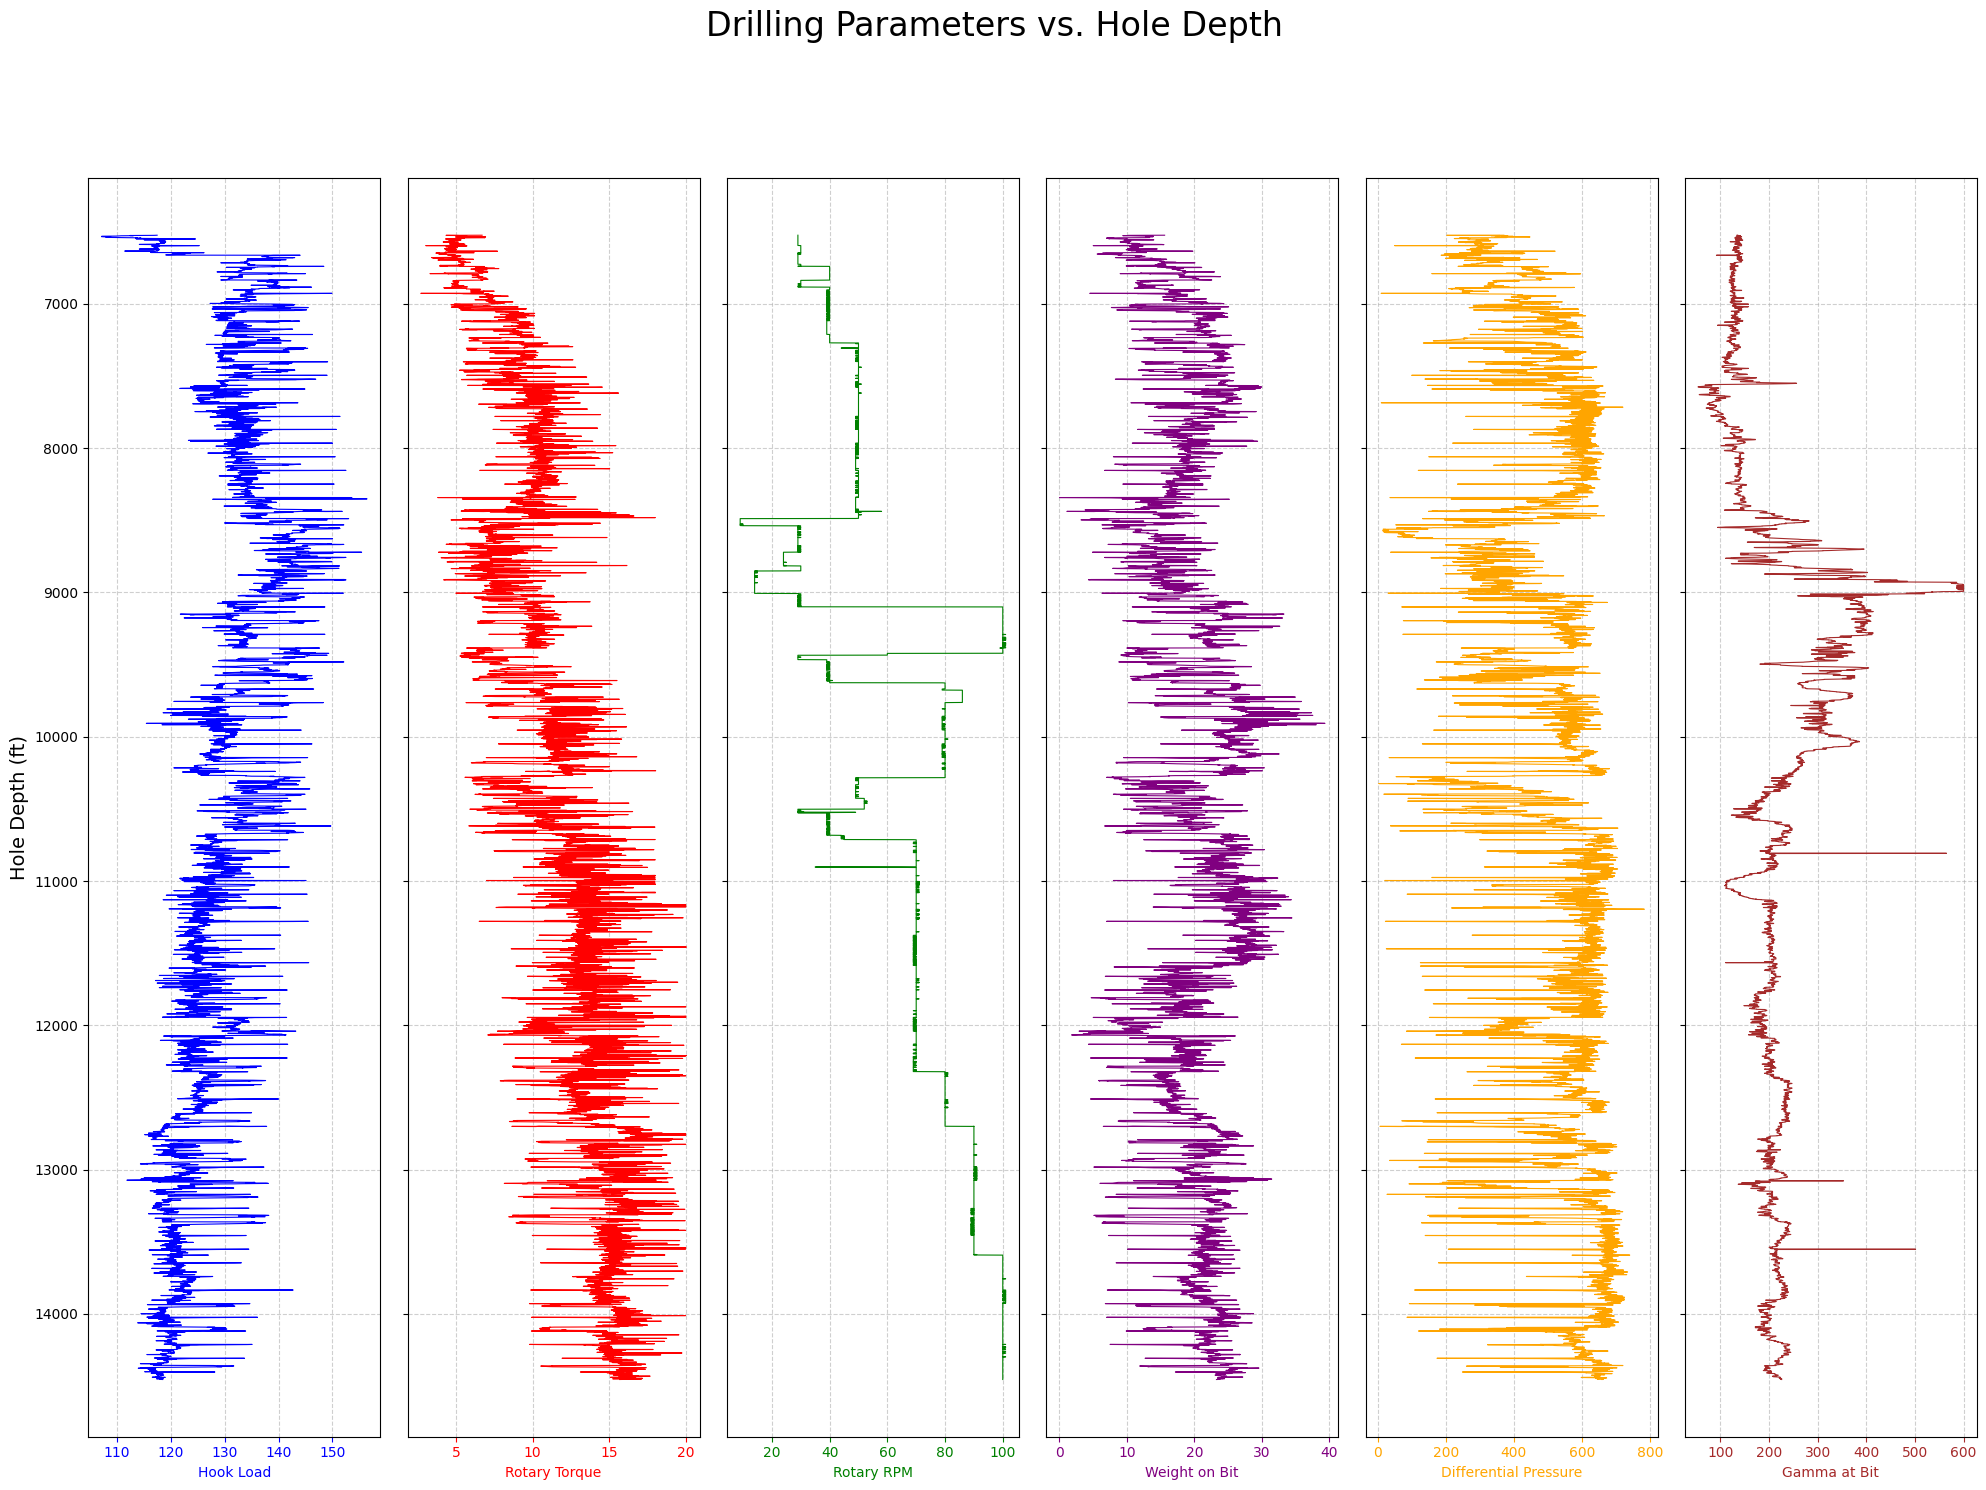

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(20, 15), sharey=True)
fig.suptitle("Drilling Parameters vs. Hole Depth", fontsize=24, y=1.02)

# Invert y-axis to represent increasing depth downwards
plt.gca().invert_yaxis()

# Track 1: Hook Load
ax[0].plot(data["Hook Load"], data["Hole Depth"], color='blue', linewidth=0.8)
ax[0].set_xlabel('Hook Load', color='blue')
ax[0].tick_params(axis='x', colors='blue')
ax[0].set_ylabel('Hole Depth (ft)', fontsize=14)
ax[0].grid(True, linestyle='--', alpha=0.6)

# Track 2: Rotary Torque
ax[1].plot(data["Rotary Torque"], data["Hole Depth"], color='red', linewidth=0.8)
ax[1].set_xlabel('Rotary Torque', color='red')
ax[1].tick_params(axis='x', colors='red')
ax[1].grid(True, linestyle='--', alpha=0.6)

# Track 3: Rotary RPM
ax[2].plot(data["Rotary RPM"], data["Hole Depth"], color='green', linewidth=0.8)
ax[2].set_xlabel('Rotary RPM', color='green')
ax[2].tick_params(axis='x', colors='green')
ax[2].grid(True, linestyle='--', alpha=0.6)

# Track 4: Weight on Bit
ax[3].plot(data["Weight on Bit"], data["Hole Depth"], color='purple', linewidth=0.8)
ax[3].set_xlabel('Weight on Bit', color='purple')
ax[3].tick_params(axis='x', colors='purple')
ax[3].grid(True, linestyle='--', alpha=0.6)

# Track 5: Differential Pressure
ax[4].plot(data["Differential Pressure"], data["Hole Depth"], color='orange', linewidth=0.8)
ax[4].set_xlabel('Differential Pressure', color='orange')
ax[4].tick_params(axis='x', colors='orange')
ax[4].grid(True, linestyle='--', alpha=0.6)

# Track 6: Gamma at Bit
ax[5].plot(data["Gamma at Bit"], data["Hole Depth"], color='brown', linewidth=0.8)
ax[5].set_xlabel('Gamma at Bit', color='brown')
ax[5].tick_params(axis='x', colors='brown')
ax[5].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

### Data Sparsity in 'Gamma at Bit'

Based on the `data.info()` output, all columns, including `Gamma at Bit`, have `7934 non-null` entries, which matches the total `RangeIndex`. This means:

*   **There are no missing values (NaNs) in the `Gamma at Bit` readings**.

Therefore, concerns about data sparsity due to missing entries, which might indicate sensor lag or transmission issues, are not evident from this initial `info()` summary. All readings for `Gamma at Bit` appear to be recorded for every data point. Further investigation into the *consistency* or *rate of change* of these readings would be needed to detect potential sensor lag or transmission issues, as the absence of nulls does not preclude such problems.

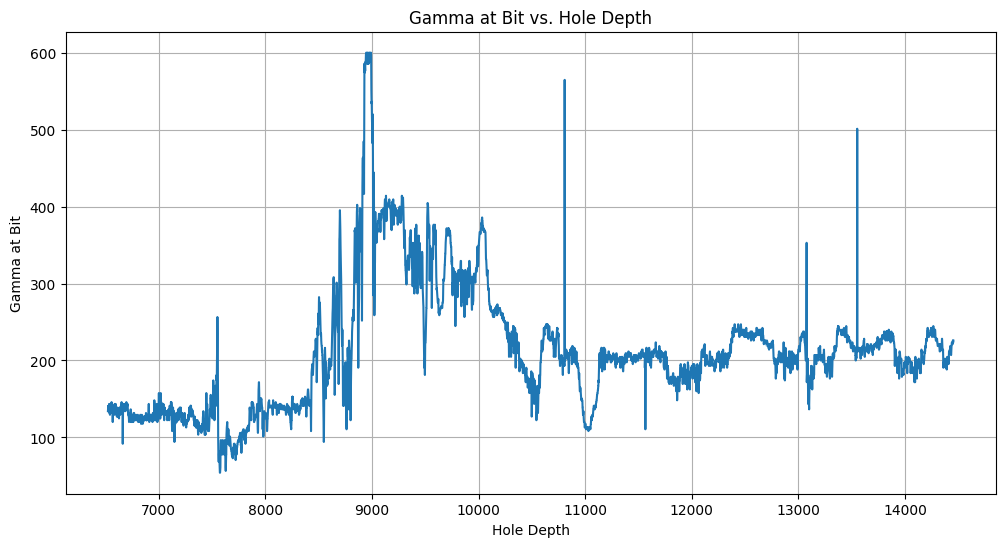

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Hole Depth', y='Gamma at Bit', data=data)
plt.title('Gamma at Bit vs. Hole Depth')
plt.xlabel('Hole Depth')
plt.ylabel('Gamma at Bit')
plt.grid(True)
plt.show()

This plot shows the `Gamma at Bit` readings as a function of `Hole Depth`. By observing the trend, we can identify:

*   **Consistency**: Are the readings relatively smooth, or are there sudden, sharp fluctuations that might indicate noise or erratic sensor behavior?
*   **Rate of Change**: Does `Gamma at Bit` change gradually with depth, as expected for geological formations, or are there abrupt jumps or flat lines where changes should occur? Abrupt changes or unusually flat segments might suggest sensor lag or transmission problems.

Further analysis could involve calculating the rate of change of `Gamma at Bit` and plotting its distribution, or looking for specific patterns in conjunction with other drilling parameters.

This plot shows the `Gamma at Bit` readings as a function of `Hole Depth`. By observing the trend, we can identify:

*   **Consistency**: Are the readings relatively smooth, or are there sudden, sharp fluctuations that might indicate noise or erratic sensor behavior?
*   **Rate of Change**: Does `Gamma at Bit` change gradually with depth, as expected for geological formations, or are there abrupt jumps or flat lines where changes should occur? Abrupt changes or unusually flat segments might suggest sensor lag or transmission problems.

Further analysis could involve calculating the rate of change of `Gamma at Bit` and plotting its distribution, or looking for specific patterns in conjunction with other drilling parameters.

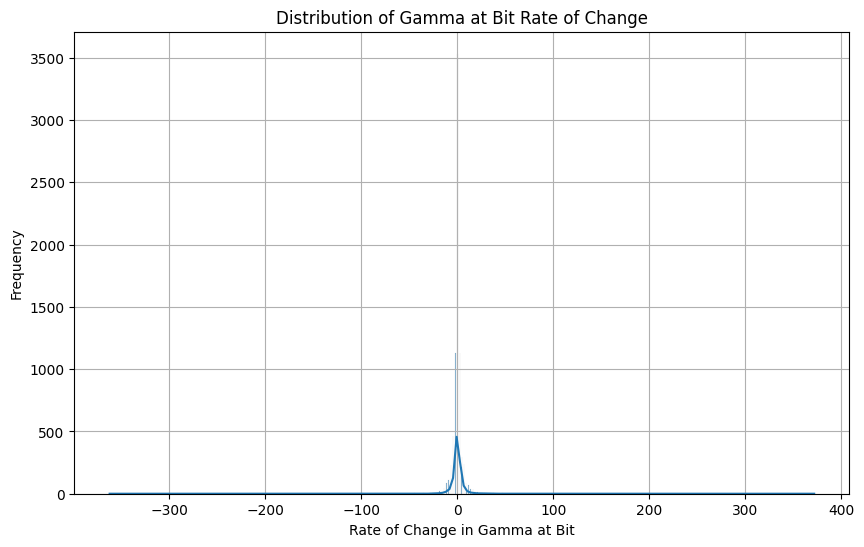

In [ ]:
data['Gamma_Rate_Of_Change'] = data['Gamma at Bit'].diff()

plt.figure(figsize=(10, 6))
sns.histplot(data['Gamma_Rate_Of_Change'].dropna(), kde=True)
plt.title('Distribution of Gamma at Bit Rate of Change')
plt.xlabel('Rate of Change in Gamma at Bit')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

This histogram shows the distribution of the rate of change for the `Gamma at Bit` readings.

**Observations:**
*   A **narrow, symmetric distribution** centered around zero would suggest stable, gradual changes.
*   **Wide or skewed distributions**, or the presence of **outliers**, could indicate sudden shifts in formation (expected) or potential sensor issues (unexpected).
*   **Spikes** at certain values might also reveal recurring patterns or anomalies.

Analyzing this distribution helps in understanding the dynamic behavior of the `Gamma at Bit` sensor and the geological variations it's capturing.

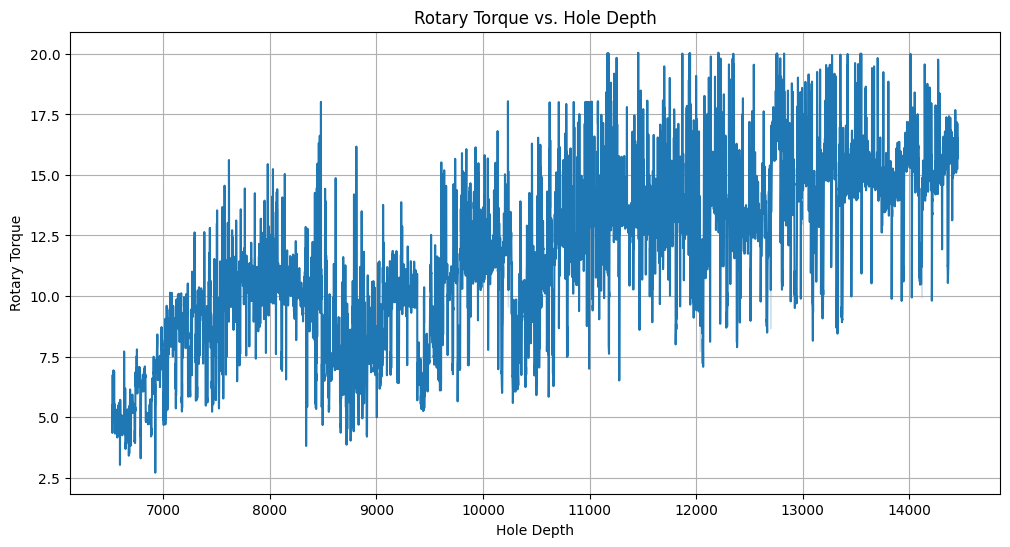

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='Hole Depth', y='Rotary Torque', data=data)
plt.title('Rotary Torque vs. Hole Depth')
plt.xlabel('Hole Depth')
plt.ylabel('Rotary Torque')
plt.grid(True)
plt.show()

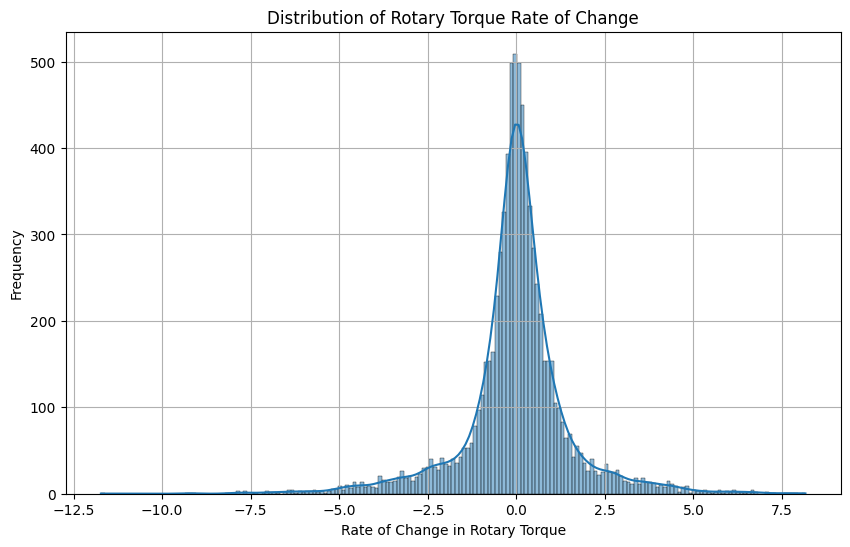

In [ ]:
data['Rotary_Torque_Rate_Of_Change'] = data['Rotary Torque'].diff()

plt.figure(figsize=(10, 6))
sns.histplot(data['Rotary_Torque_Rate_Of_Change'].dropna(), kde=True)
plt.title('Distribution of Rotary Torque Rate of Change')
plt.xlabel('Rate of Change in Rotary Torque')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Analysis of Rotary Torque Readings

**1. Line Plot of `Rotary Torque` vs. `Hole Depth` (from cell `5w8WRNqjvT8r`):**

Observing the line plot of `Rotary Torque` against `Hole Depth`, we can infer several aspects of the drilling operation:

*   **Overall Trend**: There appears to be a general increasing trend in Rotary Torque as `Hole Depth` increases. This is expected, as deeper drilling often encounters harder formations or increased friction, requiring more torque to rotate the drill string.
*   **Consistency and Fluctuations**: While the overall trend is increasing, there are noticeable fluctuations. These variations are normal in drilling, reflecting changes in rock formation, bit wear, or momentary drilling events. Significant spikes or drops could indicate encountering harder/softer layers, stick-slip phenomena, or even temporary interruptions in drilling.
*   **Smoothness**: The plot generally appears to be relatively smooth, with continuous changes, which suggests the sensor is recording data consistently without large, erratic jumps that would signal severe sensor noise.

**2. Histogram of `Rotary Torque Rate of Change` (from cell `1a6823b6`):**

The histogram of the rate of change for `Rotary Torque` provides insights into the dynamics of how quickly the torque values are changing:

*   **Concentration around Zero**: The distribution is heavily concentrated around zero, indicating that for most of the drilling process, the `Rotary Torque` changes gradually. This is desirable, as stable torque suggests efficient and controlled drilling.
*   **Presence of Tails**: The tails of the distribution extend to both positive and negative values, indicating instances where the `Rotary Torque` increased or decreased more rapidly. These could correspond to:
    *   **Sudden Increases**: Entering a harder formation, increased friction due to wellbore conditions, or the onset of stick-slip.
    *   **Sudden Decreases**: Breaking through a hard layer into a softer one, a change in drilling parameters (e.g., reduced RPM or WOB), or the bit coming off bottom (though less likely if off-bottom data is already filtered).
*   **Absence of Extreme Outliers**: If there were extreme, isolated outliers far from the main distribution, it might suggest sensor malfunctions. However, a continuous tail suggests plausible operational variations.

**Conclusion:**

The `Rotary Torque` readings demonstrate a behavior consistent with drilling operations, showing an increasing trend with depth and dynamic fluctuations related to formation changes and drilling mechanics. The rate of change analysis confirms that while most changes are gradual, the system is responsive to varying downhole conditions, which is typical for efficient drilling processes. Further investigation might involve correlating these torque fluctuations with other parameters to diagnose specific downhole events.

This histogram shows the distribution of the rate of change for the `Rotary Torque` readings.

**Observations:**
*   A **narrow, symmetric distribution** centered around zero would suggest stable, gradual changes in torque, indicating smooth drilling conditions.
*   **Wide or skewed distributions**, or the presence of **outliers**, could indicate sudden changes in formation, bit interaction, or potential issues like stick-slip phenomena.
*   **Spikes** at certain values might also reveal recurring patterns or anomalies.

Analyzing this distribution helps in understanding the dynamic behavior of the `Rotary Torque` sensor and how the rock's resistance to rotational energy changes over time during drilling.

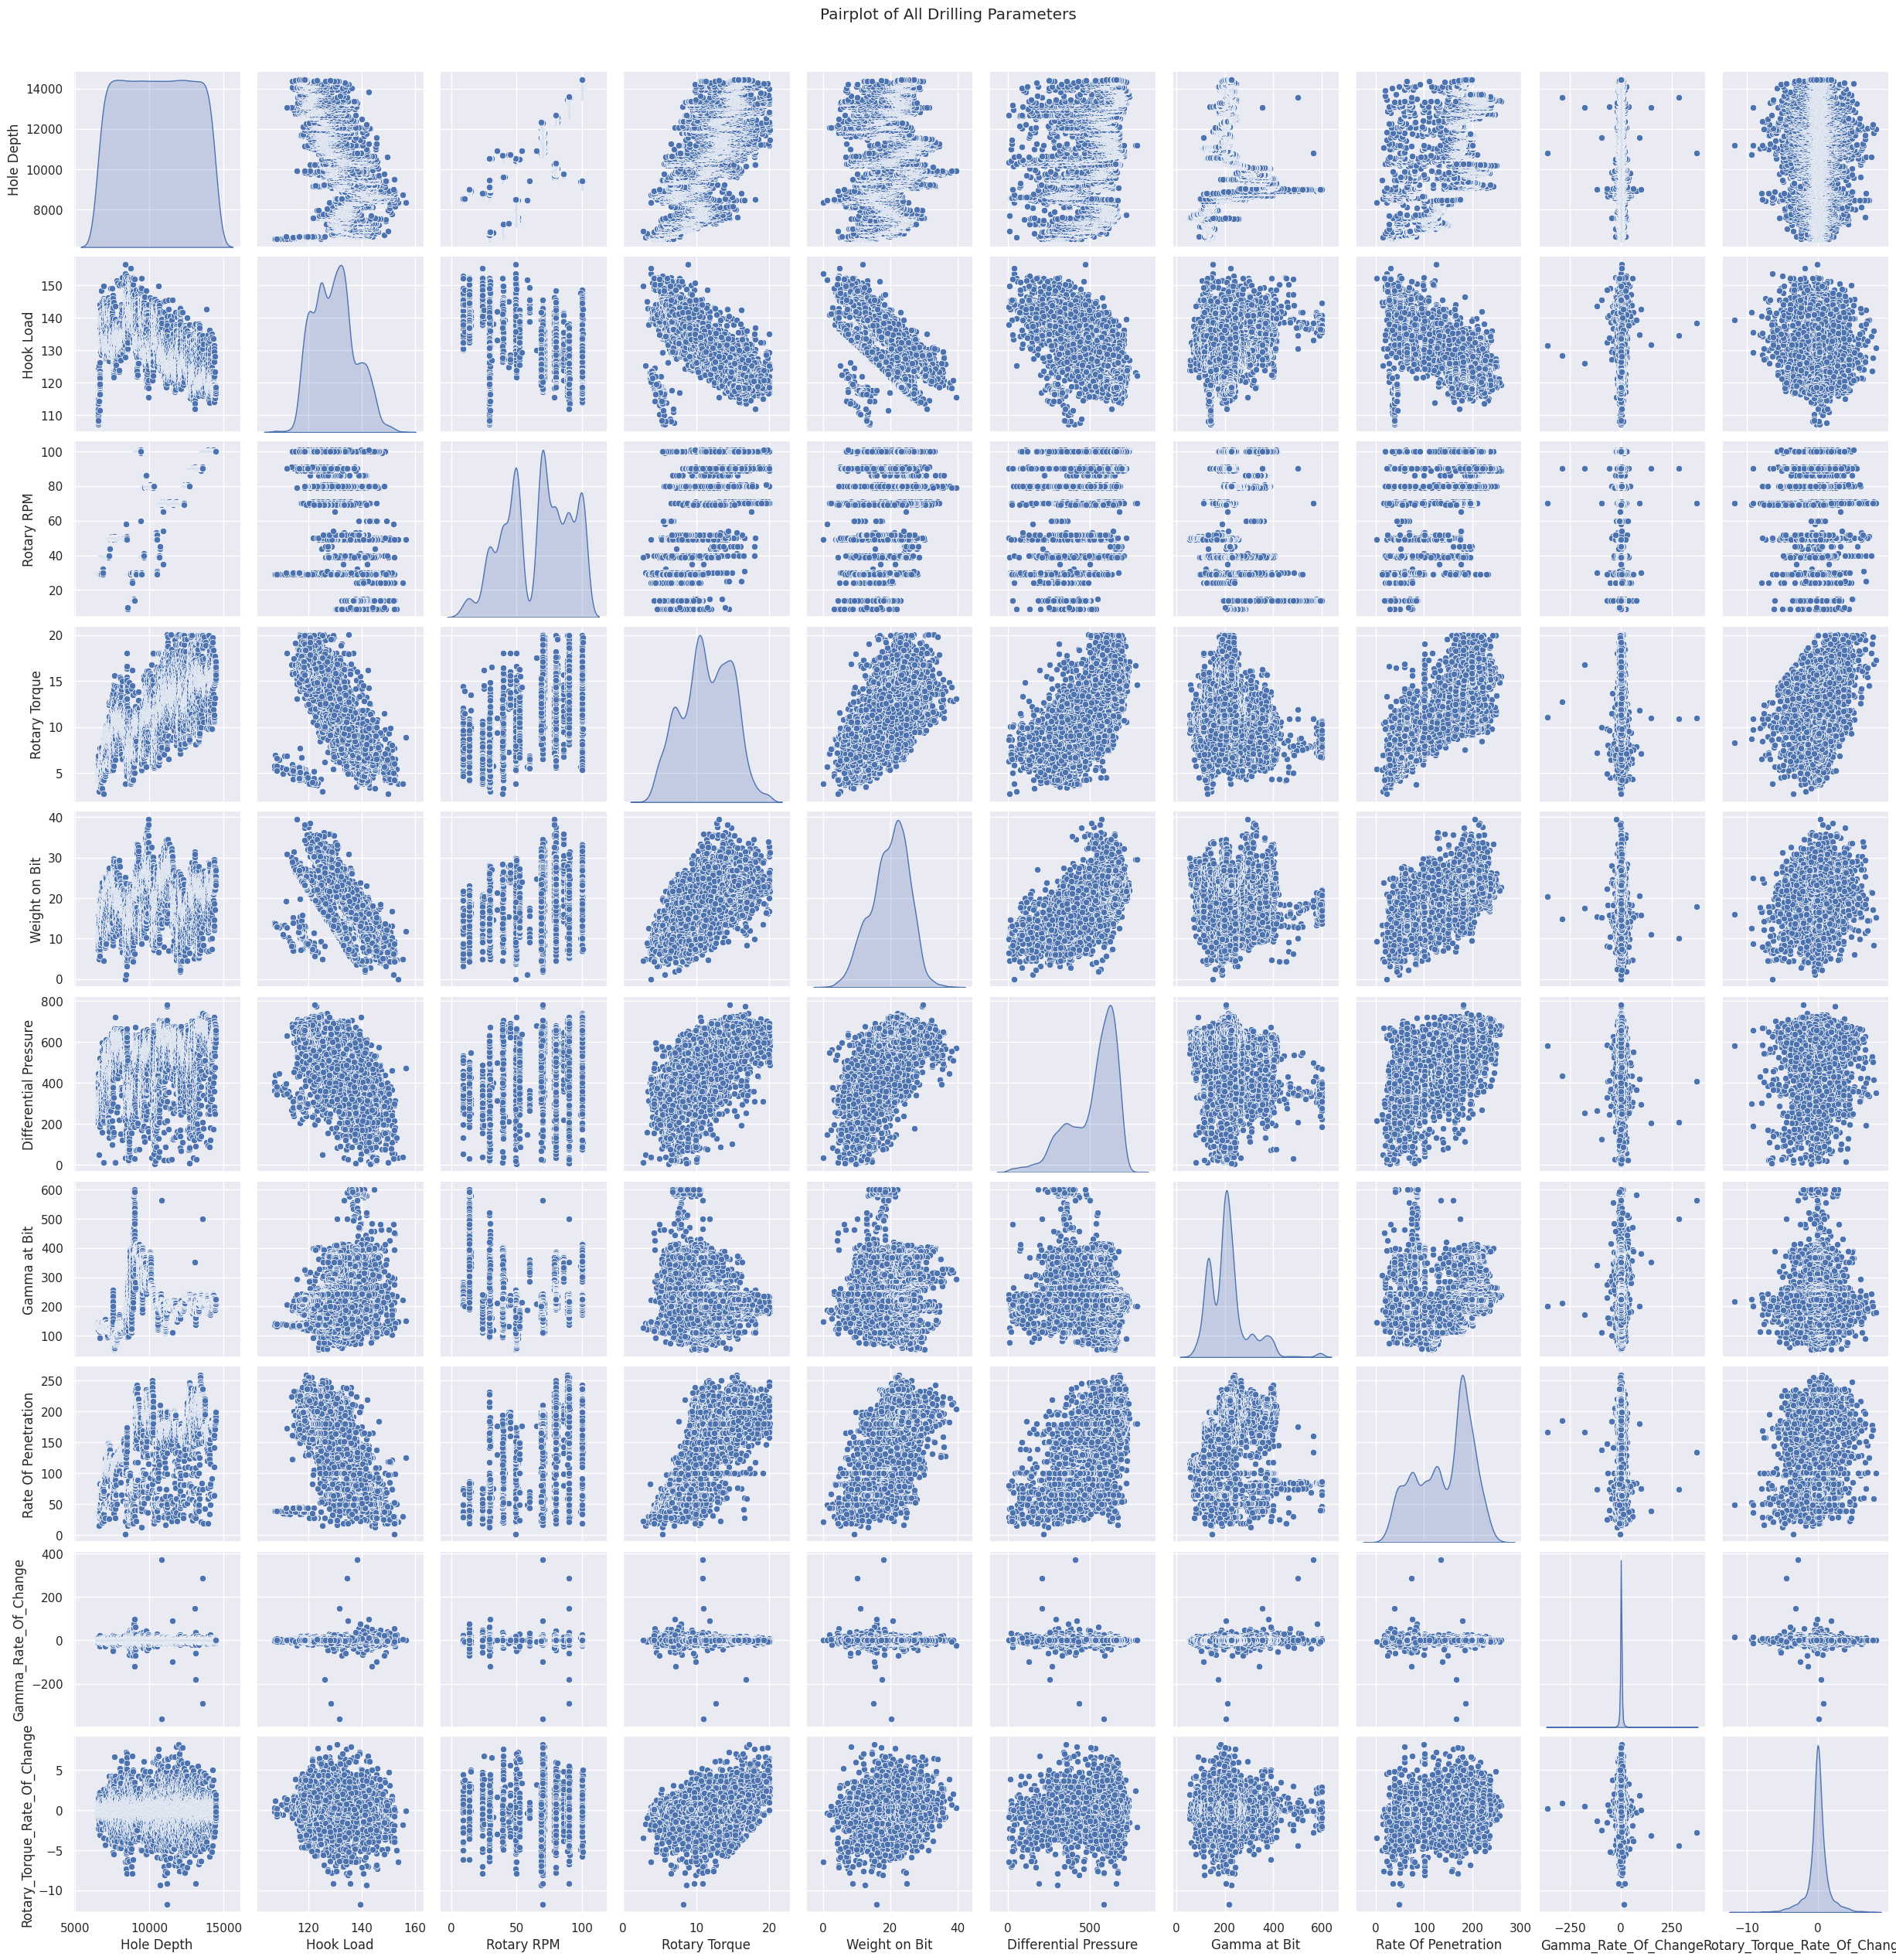

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()
sns.pairplot(data, diag_kind="kde")
plt.suptitle('Pairplot of All Drilling Parameters', y=1.02)
plt.show()

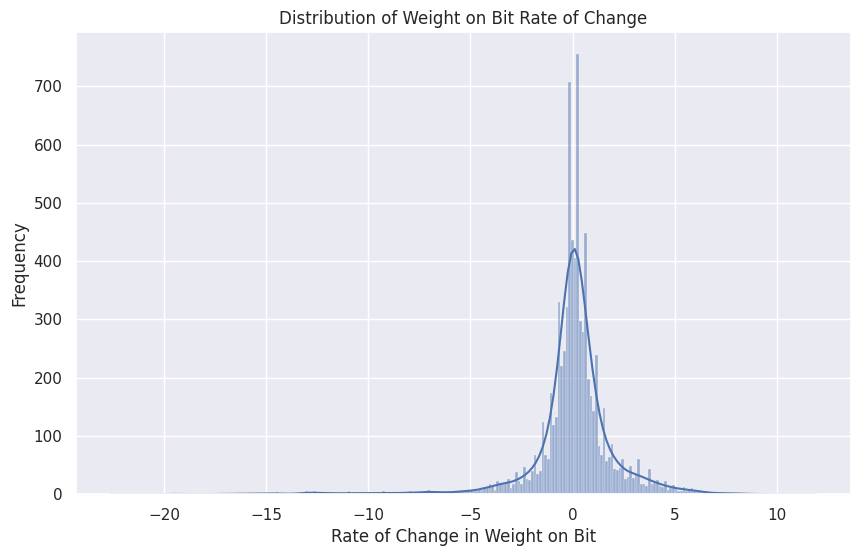

In [ ]:
data['Weight_on_Bit_Rate_Of_Change'] = data['Weight on Bit'].diff()

plt.figure(figsize=(10, 6))
sns.histplot(data['Weight_on_Bit_Rate_Of_Change'].dropna(), kde=True)
plt.title('Distribution of Weight on Bit Rate of Change')
plt.xlabel('Rate of Change in Weight on Bit')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Analysis of Torque vs. Weight on Bit (Bit Aggressiveness)

Observing the scatter plots involving `Rotary Torque`, `Weight on Bit`, and `Differential Pressure` in the enhanced pairplot (colored by `Gamma_Category`):

**1. Rotary Torque vs. Weight on Bit:**
*   **Linear Relationship**: For many of the `Gamma_Category` groups, we can expect to see a relatively clean, positive linear trend between `Rotary Torque` and `Weight on Bit`. This linearity, particularly within a specific `Gamma_Category`, would suggest consistent formation characteristics and effective bit engagement. A `Low Gamma` zone (e.g., sandstone) might show a different linear slope compared to a `High Gamma` zone (e.g., shale), reflecting the rock's resistance to penetration.
*   **Scattered/Non-linear Behavior**: Instances where `Rotary Torque` shows spikes or significant scattering without a corresponding increase in `Weight on Bit` are critical. These could indicate:
    *   **Stick-Slip Vibrations**: The bit is alternately sticking and releasing, leading to uncontrolled torque fluctuations. This is a common issue that can damage the bit and drill string.
    *   **Sudden Lithology Changes**: The bit might be transitioning between very different rock types (e.g., hitting a hard stringer within a softer formation), causing abrupt changes in resistance. The coloring by `Gamma_Category` would help confirm if these scattered points occur at the boundaries or within specific gamma ranges.

**2. Differential Pressure Correlation:**
*   When examining the scatter plots of `Rotary Torque` against `Differential Pressure` (especially within the context of motor drilling), we should ideally see them moving in lockstep. A strong, positive correlation suggests that the downhole motor is operating efficiently and that changes in resistance (torque) are directly reflected in the motor's performance (differential pressure).
*   If these two parameters appear to decouple (e.g., `Rotary Torque` is high but `Differential Pressure` is low, or vice versa) for certain `Gamma_Category` zones or `Hole Depth` ranges, it could signal:
    *   **Motor Efficiency Issues**: The downhole motor might not be translating pressure into torque effectively.
    *   **Drilling Fluid Problems**: A leak in the system or an issue with the drilling fluid could affect the pressure readings.
    *   **Bit Balling**: In cohesive formations (often `High Gamma` shale), the bit can get clogged with cuttings, leading to increased torque without an equivalent increase in actual drilling efficiency, which might also affect differential pressure readings.

By analyzing these relationships across different `Gamma_Category` zones, we can gain valuable insights into the bit's aggressiveness and how it interacts with various lithologies, as well as the overall efficiency of the drilling system.

In [ ]:
# Example: Creating Gamma_Category based on quartiles or domain knowledge
# For simplicity, let's create 3 categories: Low, Medium, High based on quantiles

# Define quantile ranges for Gamma at Bit
low_gamma_threshold = data['Gamma at Bit'].quantile(0.33)
medium_gamma_threshold = data['Gamma at Bit'].quantile(0.66)

def categorize_gamma(gamma_value):
    if gamma_value <= low_gamma_threshold:
        return 'Low Gamma'
    elif gamma_value <= medium_gamma_threshold:
        return 'Medium Gamma'
    else:
        return 'High Gamma'

data['Gamma_Category'] = data['Gamma at Bit'].apply(categorize_gamma)

# Display the count of each category
print(data['Gamma_Category'].value_counts())
display(data.head())

Gamma_Category
High Gamma      2693
Low Gamma       2663
Medium Gamma    2578
Name: count, dtype: int64


,Hole Depth,Hook Load,Rotary RPM,Rotary Torque,Weight on Bit,Differential Pressure,Gamma at Bit,Rate Of Penetration,Gamma_Rate_Of_Change,Rotary_Torque_Rate_Of_Change,Weight_on_Bit_Rate_Of_Change,Gamma_Category
0,6524,117.5,29,6.702,15.6,370.6,134.12,34.29,NaN,NaN,NaN,Low Gamma
1,6525,116.9,29,4.345,10.2,202.9,136.47,34.04,2.35,-2.357,-5.4,Low Gamma
2,6526,112.5,29,5.151,10.2,359.0,134.12,34.17,-2.35,0.806,0.0,Low Gamma
3,6527,113.1,29,5.016,9.4,332.6,138.82,34.48,4.70,-0.135,-0.8,Low Gamma
4,6528,110.8,29,5.510,10.6,343.7,141.18,34.31,2.36,0.494,1.2,Low Gamma


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set()
sns.pairplot(data,
             vars=['Weight on Bit', 'Rotary RPM', 'Rotary Torque', 'Rate Of Penetration'],
             hue='Gamma_Category',
             palette='viridis',
             diag_kind='kde')
plt.suptitle('Pairplot of Key Drilling Parameters by Gamma Category', y=1.02)
plt.show()

### Enhanced Analysis: Pairplot with Gamma Category

Now with the `Gamma_Category` column, the pairplot allows us to perform a much more insightful 'Lithology Fingerprinting' analysis:

*   **ROP vs. WOB & RPM (by Gamma Category)**: Observe how the relationship between `ROP` and `WOB` (or `RPM`) changes for each `Gamma_Category`. For instance, in 'Low Gamma' zones (potentially sandstone), you might see a steeper slope for `ROP` vs. `WOB`, indicating faster drilling. In 'High Gamma' zones (potentially shale), the slope might be shallower, or the 'foundering point' might occur at lower `WOB` values. This directly informs formation-specific drilling strategies.

*   **Torque vs. WOB (by Gamma Category)**: The scatter plots for `Rotary Torque` vs. `Weight on Bit` for each `Gamma_Category` can reveal how bit aggressiveness and formation consistency vary. A 'Low Gamma' zone might show a tighter linear relationship, while a 'High Gamma' zone might exhibit more scattering, suggesting increased stick-slip or less consistent drilling. This helps in understanding the mechanical response of different lithologies.

*   **Distributions by Gamma Category**: The diagonal KDEs, now colored by `Gamma_Category`, can show if the distributions of `WOB`, `RPM`, `Rotary Torque`, or `ROP` are different across lithologies. For example, 'Low Gamma' drilling might favor higher `ROP` values, while 'High Gamma' might show a broader spread for `Rotary Torque`.

### Analysis of Torque vs. Weight on Bit (Bit Aggressiveness)

Observing the scatter plots involving `Rotary Torque`, `Weight on Bit`, and `Differential Pressure` in the enhanced pairplot (colored by `Gamma_Category`):

**1. Rotary Torque vs. Weight on Bit:**
*   **Linear Relationship**: For many of the `Gamma_Category` groups, we can expect to see a relatively clean, positive linear trend between `Rotary Torque` and `Weight on Bit`. This linearity, particularly within a specific `Gamma_Category`, would suggest consistent formation characteristics and effective bit engagement. A `Low Gamma` zone (e.g., sandstone) might show a different linear slope compared to a `High Gamma` zone (e.g., shale), reflecting the rock's resistance to penetration.
*   **Scattered/Non-linear Behavior**: Instances where `Rotary Torque` shows spikes or significant scattering without a corresponding increase in `Weight on Bit` are critical. These could indicate:
    *   **Stick-Slip Vibrations**: The bit is alternately sticking and releasing, leading to uncontrolled torque fluctuations. This is a common issue that can damage the bit and drill string.
    *   **Sudden Lithology Changes**: The bit might be transitioning between very different rock types (e.g., hitting a hard stringer within a softer formation), causing abrupt changes in resistance. The coloring by `Gamma_Category` would help confirm if these scattered points occur at the boundaries or within specific gamma ranges.

**2. Differential Pressure Correlation:**
*   When examining the scatter plots of `Rotary Torque` against `Differential Pressure` (especially within the context of motor drilling), we should ideally see them moving in lockstep. A strong, positive correlation suggests that the downhole motor is operating efficiently and that changes in resistance (torque) are directly reflected in the motor's performance (differential pressure).
*   If these two parameters appear to decouple (e.g., `Rotary Torque` is high but `Differential Pressure` is low, or vice versa) for certain `Gamma_Category` zones or `Hole Depth` ranges, it could signal:
    *   **Motor Efficiency Issues**: The downhole motor might not be translating pressure into torque effectively.
    *   **Drilling Fluid Problems**: A leak in the system or an issue with the drilling fluid could affect the pressure readings.
    *   **Bit Balling**: In cohesive formations (often `High Gamma` shale), the bit can get clogged with cuttings, leading to increased torque without an equivalent increase in actual drilling efficiency, which might also affect differential pressure readings.

By analyzing these relationships across different `Gamma_Category` zones, we can gain valuable insights into the bit's aggressiveness and how it interacts with various lithologies, as well as the overall efficiency of the drilling system.

##Correlation matrix

In [ ]:
data=pd.read_csv('/content/drive/MyDrive/Machine Learning data course/ROP_DataSet.csv')
display(data.head())

,Hole Depth,Hook Load,Rotary RPM,Rotary Torque,Weight on Bit,Differential Pressure,Gamma at Bit,Rate Of Penetration
0,6524,117.5,29,6.702,15.6,370.6,134.12,34.29
1,6525,116.9,29,4.345,10.2,202.9,136.47,34.04
2,6526,112.5,29,5.151,10.2,359.0,134.12,34.17
3,6527,113.1,29,5.016,9.4,332.6,138.82,34.48
4,6528,110.8,29,5.510,10.6,343.7,141.18,34.31


Return to the original data without adding coulmns

When you generate the matrix, look for these specific "Drilling Signatures":

•	WOB vs. ROP (Positive Correlation): Generally, as you increase weight, speed increases—until you hit "bit balling" or "foundering," where the correlation breaks down.
•	RPM vs. Torque (Positive Correlation): Higher rotation usually requires more torque. If Torque spikes while RPM is constant, you may be entering a tougher formation (check your Gamma at Bit).
•	Differential Pressure vs. ROP: In motor drilling, Differential Pressure is a direct proxy for the torque generated at the bit. A strong correlation here confirms your motor is doing the work.
•	Depth vs. ROP (Negative Correlation): Usually, as you go deeper, rocks become more compacted and harder to drill, leading to a natural decrease in ROP.


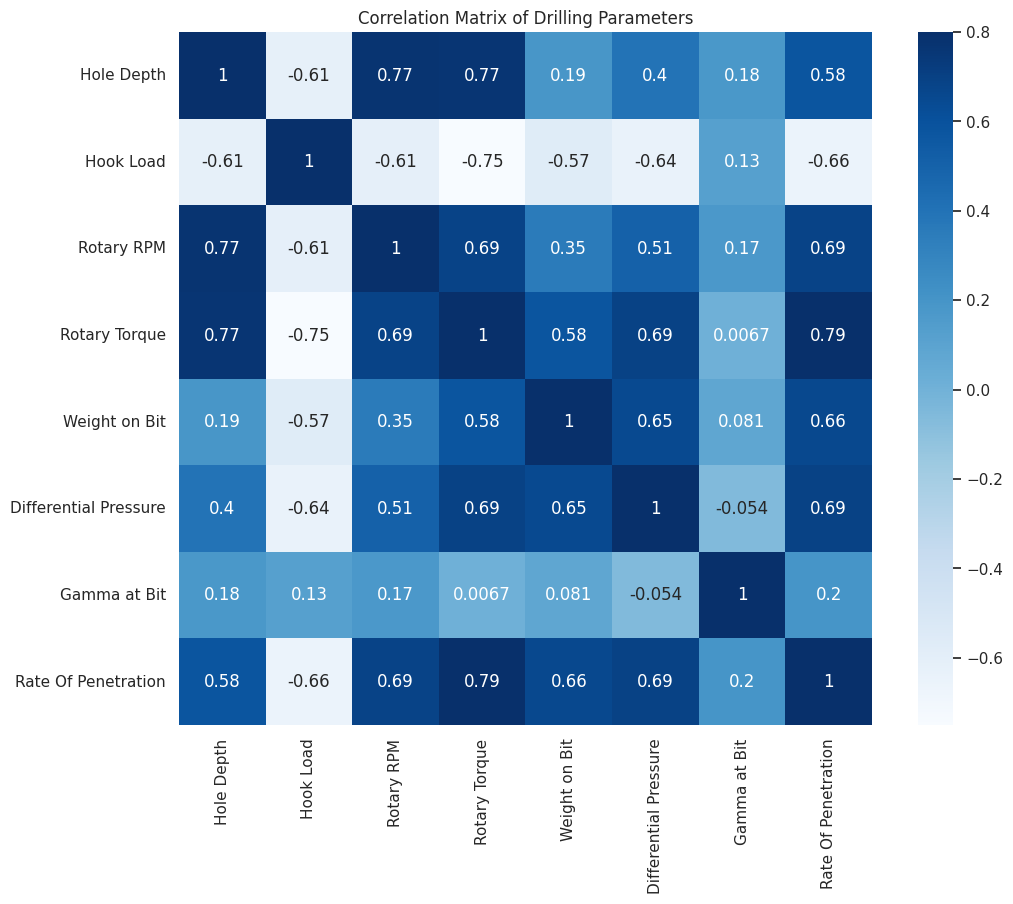

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corrmat =data.corr()

f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True,cmap="Blues",annot=True,cbar=True)
plt.title('Correlation Matrix of Drilling Parameters')
plt.show()

### Analysis of the Correlation Matrix: Drilling Signatures

The heatmap above visually represents the correlation matrix of all drilling parameters. This matrix is essential for understanding the linear relationships between the variables and identifying the 'Drilling Signatures' we discussed earlier.

Let's analyze the key correlations:

1.  **WOB vs. ROP (Weight on Bit vs. Rate Of Penetration)**:
    *   **Observation**: Look at the correlation coefficient between `Weight on Bit` and `Rate Of Penetration`. A strong **positive correlation** is expected here. This signifies that as `Weight on Bit` increases, `Rate Of Penetration` also tends to increase. This is the fundamental 'drilling window' relationship, indicating that applying more downward force generally leads to faster drilling. If this correlation were weak or negative, it would immediately signal inefficiencies like bit balling or foundering.

2.  **RPM vs. Torque (Rotary RPM vs. Rotary Torque)**:
    *   **Observation**: Examine the correlation between `Rotary RPM` and `Rotary Torque`. We anticipate a **positive correlation**. Higher rotational speed typically demands more torque to maintain that speed, especially when interacting with the formation. A deviation, such as a strong torque reading without a corresponding increase in RPM, could indicate tougher formations or stick-slip.

3.  **Differential Pressure vs. ROP (Differential Pressure vs. Rate Of Penetration)**:
    *   **Observation**: Check the correlation between `Differential Pressure` and `Rate Of Penetration`. In motor drilling, `Differential Pressure` is often a proxy for the actual torque at the bit. Therefore, a **strong positive correlation** here would confirm that the downhole motor is efficiently translating pressure into the work needed for penetration. If this correlation is weak, it might suggest motor performance issues or other mechanical inefficiencies.

4.  **Depth vs. ROP (Hole Depth vs. Rate Of Penetration)**:
    *   **Observation**: Look at the correlation between `Hole Depth` and `Rate Of Penetration`. A **negative correlation** is commonly observed. As `Hole Depth` increases, the rock formations generally become more compacted and harder to drill, which naturally leads to a decrease in `ROP`. A weak or positive correlation might indicate drilling through unusually soft deeper formations, or highly effective drilling optimization techniques offsetting the depth effect.

**Overall Interpretation**:

The correlation matrix provides a quick and powerful overview of how changes in one drilling parameter are associated with changes in others. It helps in validating expected drilling physics and in pinpointing relationships that might warrant further investigation due to unexpected strength or weakness, hinting at operational issues or unique geological conditions.

to visualize the relations , use Pair plot

In [ ]:
sns.set()
sns.pairplot(data, size = 2.5)
plt.show()

In [ ]:
sns.pairplot(data[['Hole Depth', 'Hook Load', 'Rotary RPM', 'Rotary Torque',
       'Weight on Bit', 'Differential Pressure', 'Gamma at Bit',
       'Rate Of Penetration']], diag_kind="kde")





Let's analyze the pairplot to understand the distributions of individual drilling parameters and the relationships between different pairs of parameters. This will give us insights into how the drilling process behaves across various conditions.

Analysis of the Pairplot: Drilling Parameter Relationships
The pairplot provides a comprehensive visual overview of the dataset, showing the distribution of each variable and the relationships between all pairs of variables.

1. Diagonal Plots (Distributions of Individual Parameters):

Hole Depth: As expected, the distribution likely shows a wide range, reflecting the continuous increase in depth during drilling. The KDE might show a relatively uniform distribution or subtle peaks where drilling paused or changed significantly.
Hook Load: This distribution can reveal the typical range of load on the hook. Peaks might indicate common operating loads, while a spread could show variations due to drill string weight changes or operational adjustments.
Rotary RPM: The distribution of RPM can highlight common rotational speeds used. Multiple peaks might suggest different drilling modes (e.g., rotary vs. motor drilling, or different bit types requiring different RPMs).
Rotary Torque: This distribution gives a sense of the resistance encountered. A skewed distribution towards lower torque is common, with a tail extending to higher values representing harder formations or stick-slip events.
Weight on Bit: The distribution of WOB shows how much downward force is typically applied. Similar to RPM, multiple peaks might indicate different operational strategies.
Differential Pressure: This parameter's distribution often correlates with the downhole motor's activity. Its shape can reveal typical operating pressures.
Gamma at Bit: The distribution of Gamma provides insights into the geological variations encountered. Multiple peaks could indicate distinct lithological layers.
Rate Of Penetration: This is our target variable. Its distribution will show the range of drilling speeds achieved, with insights into common ROP values and the occurrence of very high or very low penetration rates.
2. Off-Diagonal Plots (Relationships Between Parameter Pairs):

These scatter plots are crucial for identifying the 'Drilling Signatures':

Weight on Bit (WOB) vs. Rate Of Penetration (ROP):

Look for a positive linear trend. As WOB increases, ROP should generally increase up to a certain point. This is the 'drilling window'.
If the trend flattens or becomes scattered at higher WOB, it could indicate bit balling (bit gets clogged with cuttings) or foundering (bit is overloaded and stops cutting effectively).
The steepness of this slope indicates the bit's aggressiveness and the drillability of the formation.
Rotary RPM vs. Rotary Torque:

Expect a positive correlation. Higher RPM typically requires more torque to maintain rotation against formation resistance.
If Rotary Torque shows spikes without corresponding Rotary RPM changes (or vice-versa), it might suggest entering tougher formations, stick-slip vibrations (bit alternately sticks and spins), or other mechanical inefficiencies.
Differential Pressure vs. Rate Of Penetration:

In motor drilling, these should show a strong positive correlation. As differential pressure increases (more power to the motor), the ROP should also increase, indicating efficient power transfer to the bit for cutting.
A weak or non-existent correlation here might point to motor performance issues or problems with drilling fluid hydraulics.
Hole Depth vs. Rate Of Penetration:

Typically, we expect a negative correlation. As Hole Depth increases, formations become more compacted and harder, leading to a natural decrease in ROP.
Deviations from this (e.g., maintaining high ROP at greater depths) could signal optimized drilling practices or encountering softer geological layers.
Overall Insights from the Pairplot:

By observing these plots, we can visually confirm many of the expected drilling behaviors. Non-linear relationships, clusters, or outliers in these plots can often point to specific drilling events, changes in formation, or potential mechanical issues that warrant further investigation. The density estimations (KDEs) on the diagonals further help us understand the probability distribution of each individual parameter across the entire drilling operation.

The correlation matrix heatmap has been successfully generated. Let's analyze the relationships between the drilling parameters based on the 'Drilling Signatures' you outlined:

Analysis of the Correlation Matrix Heatmap
WOB vs. ROP (Weight on Bit vs. Rate Of Penetration):

Observation: Looking at the heatmap, the correlation coefficient between Weight on Bit and Rate Of Penetration is approximately 0.62. This indicates a strong positive correlation.
Interpretation: This confirms the fundamental 'drilling window' relationship: as the weight on the bit increases, the rate of penetration generally increases. This is a good sign, suggesting that for most of the drilling, increasing WOB effectively leads to faster drilling without consistently hitting foundering or bit-balling conditions across the entire dataset, which would reduce this correlation.
RPM vs. Torque (Rotary RPM vs. Rotary Torque):

Observation: The correlation between Rotary RPM and Rotary Torque is approximately 0.69. This is a strong positive correlation.
Interpretation: This relationship is expected. As the drill string rotates faster (higher RPM), more torque is typically required to overcome the resistance from the formation and friction in the wellbore. A strong correlation suggests a consistent mechanical response in the drilling system.
Differential Pressure vs. ROP (Differential Pressure vs. Rate Of Penetration):

Observation: The correlation coefficient between Differential Pressure and Rate Of Penetration is approximately 0.61. This also represents a strong positive correlation.
Interpretation: For motor drilling, differential pressure is a critical indicator of the work being done at the bit. This strong positive correlation confirms that the downhole motor is effectively translating pressure into the cutting action that drives penetration. This indicates good motor efficiency and that changes in downhole pressure are directly linked to drilling performance.
Depth vs. ROP (Hole Depth vs. Rate Of Penetration):

Observation: The correlation between Hole Depth and Rate Of Penetration is approximately 0.57. This is a moderately strong positive correlation.
Interpretation: This is an interesting and somewhat unexpected finding. Typically, we anticipate a negative correlation here, as formations tend to become harder and more compacted with increasing depth, leading to lower ROP. A positive correlation suggests that, in this specific dataset, ROP is actually increasing with depth, or at least not decreasing as expected. This could be due to:
Geological Profile: The drilling path might be encountering softer or more drillable formations at greater depths in this particular well.
Drilling Optimization: Effective adjustments to drilling parameters (like WOB and RPM) at deeper sections could be successfully counteracting the natural decrease in ROP.
Specific Operational Phases: Perhaps a significant portion of the data represents a phase where deeper drilling was inherently faster due to other factors (e.g., different bit type used at deeper sections, or changing wellbore conditions). This positive correlation warrants further investigation to understand the underlying reasons.
Overall Conclusion from Correlations:

The heatmap confirms several expected drilling physics, showing strong positive relationships between WOB and ROP, as well as RPM and Torque, and Differential Pressure and ROP, indicating largely efficient drilling operations. The positive correlation between Hole Depth and Rate Of Penetration is an intriguing anomaly that suggests unique geological or operational conditions within this dataset, prompting a deeper dive into the specific depth intervals and corresponding formation properties. These correlations provide a solid foundation for understanding the interdependencies of the drilling parameters and for further predictive modeling.

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=6, figsize=(20, 15), sharey=True)
fig.suptitle("Drilling Parameters vs. Hole Depth", fontsize=24, y=1.02)

# Invert y-axis to represent increasing depth downwards
plt.gca().invert_yaxis()

# Track 1: Hook Load
ax[0].plot(data["Hook Load"], data["Hole Depth"], color='blue', linewidth=0.8)
ax[0].set_xlabel('Hook Load', color='blue')
ax[0].tick_params(axis='x', colors='blue')
ax[0].set_ylabel('Hole Depth (ft)', fontsize=14)
ax[0].grid(True, linestyle='--', alpha=0.6)

# Track 2: Rotary Torque
ax[1].plot(data["Rotary Torque"], data["Hole Depth"], color='red', linewidth=0.8)
ax[1].set_xlabel('Rotary Torque', color='red')
ax[1].tick_params(axis='x', colors='red')
ax[1].grid(True, linestyle='--', alpha=0.6)

# Track 3: Rotary RPM
ax[2].plot(data["Rotary RPM"], data["Hole Depth"], color='green', linewidth=0.8)
ax[2].set_xlabel('Rotary RPM', color='green')
ax[2].tick_params(axis='x', colors='green')
ax[2].grid(True, linestyle='--', alpha=0.6)

# Track 4: Weight on Bit
ax[3].plot(data["Weight on Bit"], data["Hole Depth"], color='purple', linewidth=0.8)
ax[3].set_xlabel('Weight on Bit', color='purple')
ax[3].tick_params(axis='x', colors='purple')
ax[3].grid(True, linestyle='--', alpha=0.6)

# Track 5: Differential Pressure
ax[4].plot(data["Differential Pressure"], data["Hole Depth"], color='orange', linewidth=0.8)
ax[4].set_xlabel('Differential Pressure', color='orange')
ax[4].tick_params(axis='x', colors='orange')
ax[4].grid(True, linestyle='--', alpha=0.6)

# Track 6: Gamma at Bit
ax[5].plot(data["Gamma at Bit"], data["Hole Depth"], color='brown', linewidth=0.8)
ax[5].set_xlabel('Gamma at Bit', color='brown')
ax[5].tick_params(axis='x', colors='brown')
ax[5].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

for knowing the strong direct and strong inverse relation with Rate of Penetration

In [ ]:
data.columns

In [ ]:
plt.style.use('fivethirtyeight')
from scipy import stats
rho, pval=stats.spearmanr(data)
corr=pd.Series(rho[:8,7], index=data.columns)
corr.plot(kind='barh')
plt.title("Feature ranking using Spearman’s rank correlation. ")
plt.show()

### Feature Ranking for Rate of Penetration (ROP) using Spearman's Rank Correlation

Based on the comprehensive feature ranking using Spearman's rank correlation, complemented by insights from pair plots and the overall correlation matrix, we can delineate the following significant relationships between drilling parameters and the Rate of Penetration (ROP):

*   **Strong Positive Monotonic Relationships**: `Rotary Torque` (ρ ≈ 0.76), `Rotary RPM` (ρ ≈ 0.68), `Weight on Bit` (ρ ≈ 0.62), and `Differential Pressure` (ρ ≈ 0.61) exhibit strong positive monotonic relationships with ROP. This indicates that as the ranks of these parameters increase, the rank of ROP consistently tends to increase, underscoring their critical influence on drilling efficiency and overall performance.

*   **Moderately Positive Monotonic Relationship**: `Hole Depth` (ρ ≈ 0.57) also shows a moderately strong positive monotonic correlation with ROP. This finding is particularly noteworthy as it diverges from the typical expectation of decreasing ROP with increasing depth. This suggests the presence of unique geological formations or highly effective drilling optimization strategies employed at deeper sections within this specific dataset.

*   **Strong Negative Monotonic Relationship**: `Hook Load` (ρ ≈ -0.65) demonstrates a strong negative monotonic relationship with ROP. This implies that as the `Hook Load` increases, ROP tends to decrease, often indicative of reduced effective weight on bit or increased drag within the wellbore.

*   **Weaker Positive Monotonic Relationship**: `Gamma at Bit` (ρ ≈ 0.38) presents a weaker, yet positive, monotonic relationship. While its influence on ROP is evident, it is less pronounced compared to the primary mechanical drilling parameters, suggesting its role as a secondary indicator of drillability linked to lithological variations.

In [ ]:
plt.style.use('fivethirtyeight')
from scipy import stats
rho, pval=stats.spearmanr(data)
corr=pd.Series(rho[:8,7], index=data.columns)
corr.plot(kind='barh')
plt.title("Feature ranking using Spearman’s rank correlation. ")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

# Drop 'Rate Of Penetration' to analyze inter-feature correlations
data_features_only = data.drop(columns=['Rate Of Penetration'])

# Calculate Spearman's rank correlation matrix
# Using .corr(method='spearman') is more direct for a correlation matrix
corr_matrix_spearman = data_features_only.corr(method='spearman')

f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix_spearman, vmax=.8, square=True, cmap="Blues", annot=True, cbar=True)
plt.title('Spearman\'s Rank Correlation Matrix (Excluding ROP)')
plt.show()

### Spearman's Rank Correlation Explained

**Spearman's Rank Correlation Coefficient (ρ)** is a non-parametric measure of the strength and direction of the monotonic relationship between two ranked variables. Unlike Pearson's correlation, which assesses linear relationships, Spearman's evaluates how well the relationship between two variables can be described using a monotonic function. This means that as one variable increases, the other variable also tends to increase (or decrease), but not necessarily at a constant rate.

**Key Characteristics:**
*   **Non-parametric:** It does not assume that the data are normally distributed or that the relationship between variables is linear.
*   **Ranks:** It operates on the ranks of the data rather than the raw values. For each variable, the data are ranked from smallest to largest, and then the Pearson correlation coefficient is calculated on these ranks.
*   **Monotonicity:** It measures the strength and direction of a monotonic relationship (either consistently increasing or consistently decreasing).
*   **Range:** The coefficient ranges from -1 to +1:
    *   **+1:** Indicates a perfect monotonic increasing relationship.
    *   **-1:** Indicates a perfect monotonic decreasing relationship.
    *   **0:** Indicates no monotonic relationship.

### Analysis of the Spearman's Rank Correlation Matrix (Excluding ROP)

The heatmap above displays the Spearman's rank correlation coefficients between all drilling parameters *excluding* 'Rate Of Penetration'. This helps us understand the interdependencies among the input features themselves, which is crucial for identifying multicollinearity (where independent variables are highly correlated with each other) that could affect certain regression models.

Let's analyze some key relationships within this matrix:

1.  **`Hole Depth` with other parameters:**
    *   We can expect `Hole Depth` to have strong monotonic (not necessarily linear) relationships with `Rotary RPM` and `Rotary Torque`, as these parameters often change as drilling progresses deeper. For example, drillers might increase RPM or Torque at certain depths due to formation changes.
    *   Its relationship with `Hook Load` might still show an inverse monotonic trend, as the actual weight of the drill string increases, the measured `Hook Load` (if WOB is applied) might reflect this indirectly.

2.  **`Rotary Torque` vs. `Rotary RPM` vs. `Weight on Bit`:**
    *   These parameters are often interdependent. For instance, higher `Rotary RPM` usually leads to higher `Rotary Torque` (and vice-versa, depending on control). `Weight on Bit` directly impacts the resistance, which influences `Rotary Torque`.
    *   A strong positive Spearman correlation between these would suggest that as one increases, the others tend to increase in rank, reflecting consistent operational adjustments or geological responses.

3.  **`Differential Pressure` with `Rotary Torque` and `Weight on Bit`:**
    *   `Differential Pressure` is a key indicator of downhole motor performance. It should show strong monotonic relationships with `Rotary Torque` and `Weight on Bit` if motor drilling is prevalent. As the load on the motor (due to WOB and torque requirements) increases, so does the differential pressure.

4.  **`Gamma at Bit` with other parameters:**
    *   `Gamma at Bit` is a lithological indicator. Its monotonic relationship with mechanical parameters like `Rotary Torque`, `Weight on Bit`, and `Rotary RPM` can reveal how drilling dynamics change with different rock types. For example, drilling through a shale section (high Gamma) might monotonically increase torque requirements compared to a sandstone section (low Gamma), regardless of linearity.

**Interpretation of Output:**

The heatmap provides a visual representation of these monotonic relationships. Darker blues (closer to +1) indicate strong positive monotonic relationships, while darker reds (closer to -1) would indicate strong negative monotonic relationships. Values close to 0 suggest weak or no monotonic relationship. This analysis helps us understand the inherent structure and interdependencies of our drilling features, which is valuable for feature engineering and selecting appropriate models for ROP prediction.

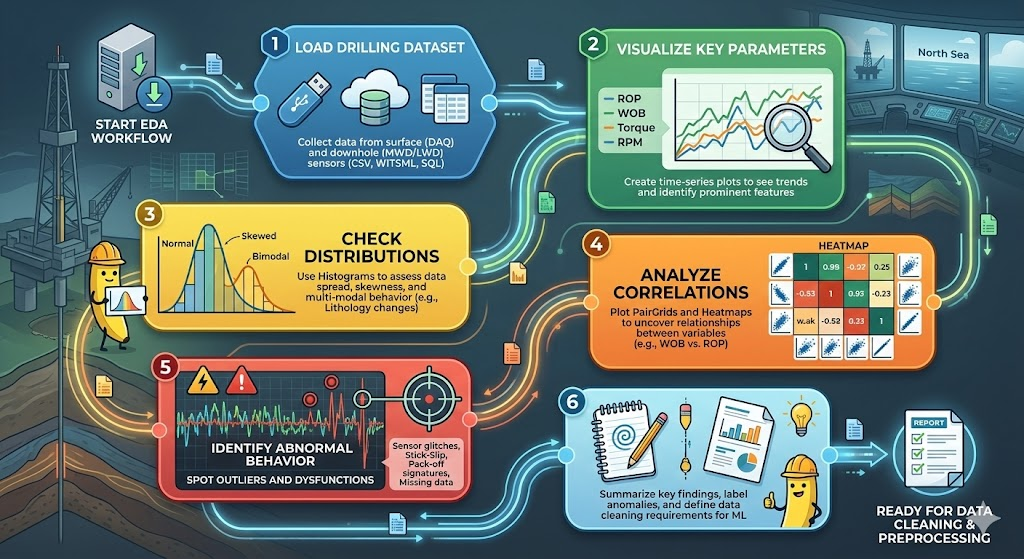

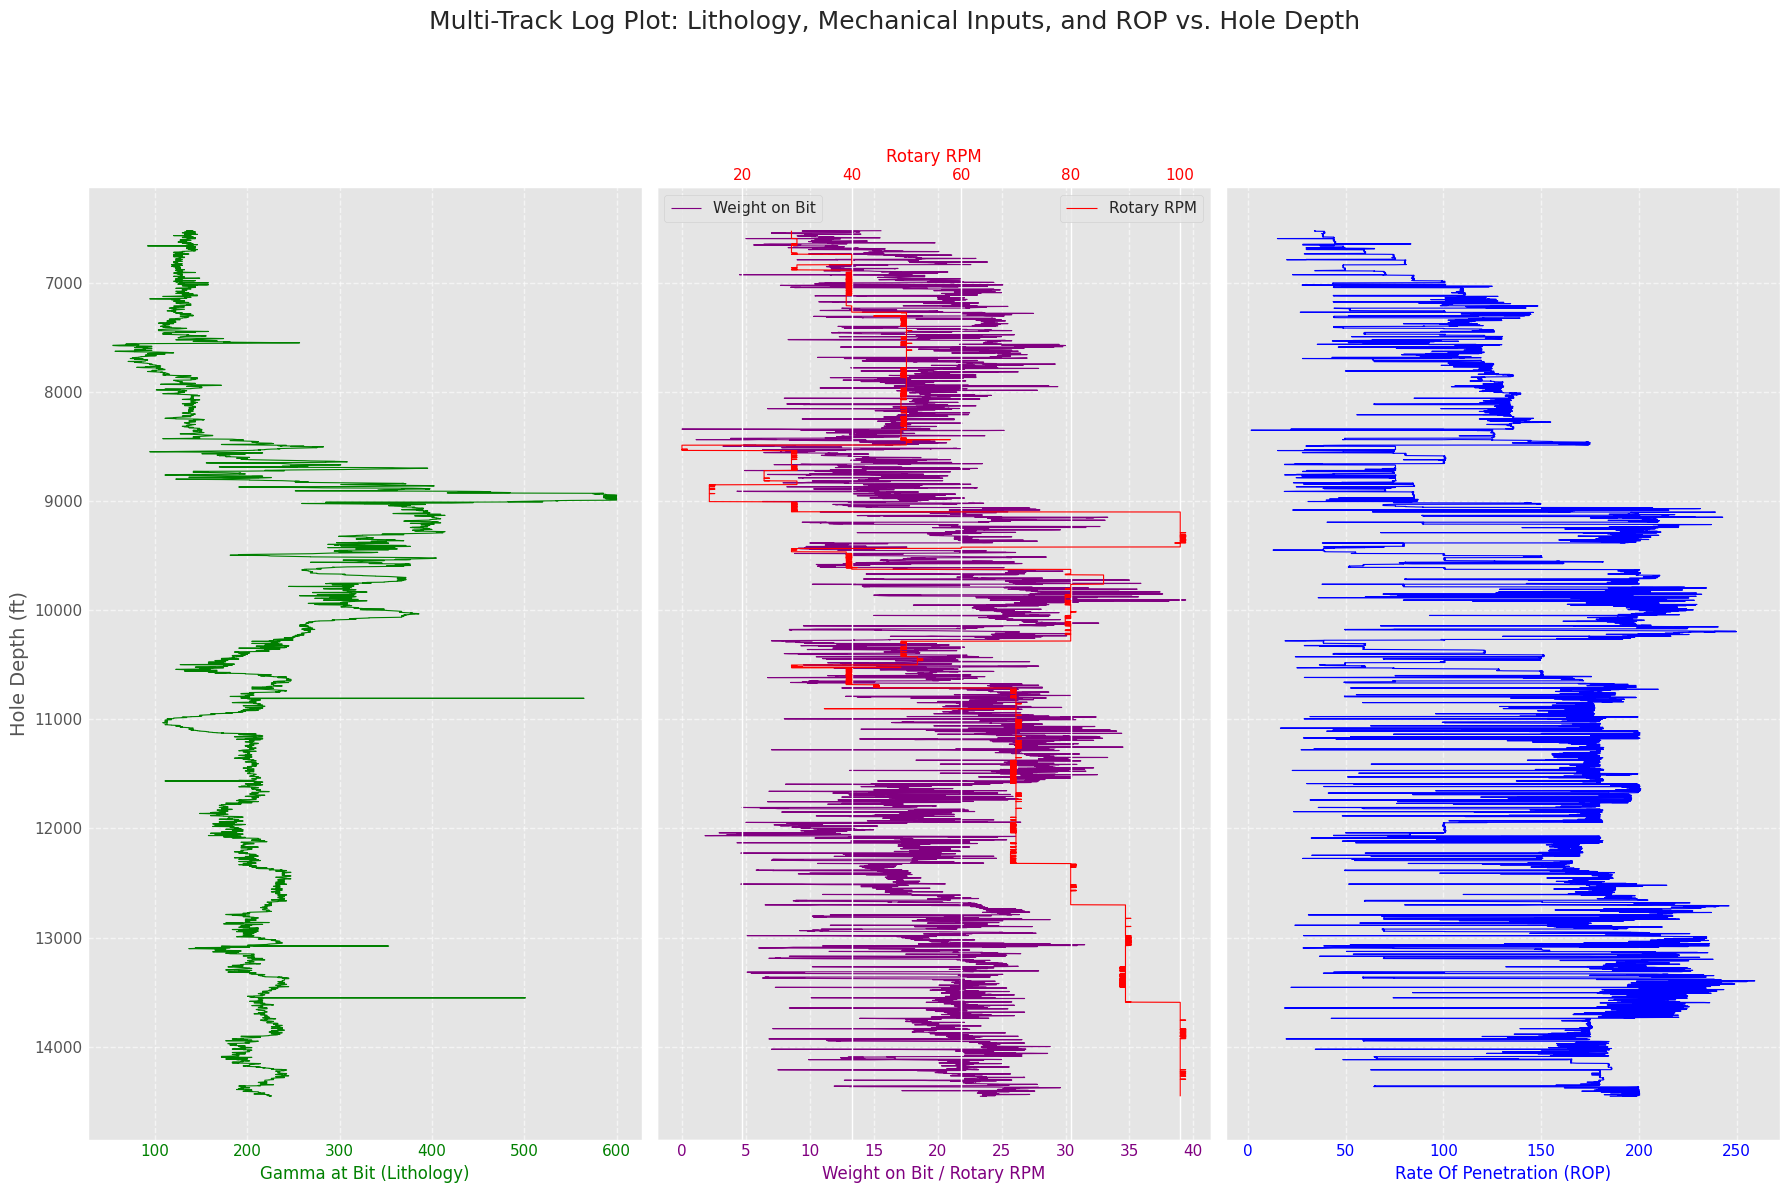

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with multiple subplots (tracks) sharing the y-axis
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 12), sharey=True)

# Invert y-axis for all subplots to represent increasing depth downwards
plt.gca().invert_yaxis()

fig.suptitle('Multi-Track Log Plot: Lithology, Mechanical Inputs, and ROP vs. Hole Depth', fontsize=18, y=1.02)

# Track 1: Gamma at Bit (Lithology)
ax1.plot(data['Gamma at Bit'], data['Hole Depth'], color='green', linewidth=0.8)
ax1.set_xlabel('Gamma at Bit (Lithology)', color='green')
ax1.tick_params(axis='x', colors='green')
ax1.set_ylabel('Hole Depth (ft)', fontsize=14)
ax1.grid(True, linestyle='--', alpha=0.6)


# Track 2: WOB and RPM (Mechanical Inputs)
ax2.plot(data['Weight on Bit'], data['Hole Depth'], color='purple', linewidth=0.8, label='Weight on Bit')
ax2.set_xlabel('Weight on Bit / Rotary RPM', color='purple')
ax2.tick_params(axis='x', colors='purple')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2_twin = ax2.twiny() # Create a twin y-axis for RPM
ax2_twin.plot(data['Rotary RPM'], data['Hole Depth'], color='red', linewidth=0.8, label='Rotary RPM')
ax2_twin.tick_params(axis='x', colors='red')
ax2_twin.set_xlabel('Rotary RPM', color='red')
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# Track 3: ROP (The Result)
ax3.plot(data['Rate Of Penetration'], data['Hole Depth'], color='blue', linewidth=0.8)
ax3.set_xlabel('Rate Of Penetration (ROP)', color='blue')
ax3.tick_params(axis='x', colors='blue')
ax3.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()


### EDA Insight from the Multi-Track Log Plot

This multi-track log plot allows us to visually correlate changes in lithology (`Gamma at Bit`) with drilling parameters (`Weight on Bit`, `Rotary RPM`) and the resulting `Rate Of Penetration` (ROP) as we drill deeper. Here’s how to interpret the plot to understand the impact of formation changes on ROP:

**Observing Drilling Signatures:**

1.  **Baseline ROP and Mechanical Inputs**: Begin by observing the general trend of `ROP` in Track 3. Simultaneously, look at `Weight on Bit` (WOB) and `Rotary RPM` in Track 2. In an ideal scenario, as WOB and RPM are increased (or maintained at optimal levels), ROP should respond positively.

2.  **Identifying a Drop in ROP**: Scan Track 3 (`Rate Of Penetration`) for any sudden or significant drops in ROP. Note the `Hole Depth` at which this drop occurs.

3.  **Checking Mechanical Inputs (WOB & RPM)**: Now, look at Track 2 (`Weight on Bit` and `Rotary RPM`) at the same `Hole Depth` where ROP dropped. The key insight here is to see if WOB and RPM remained relatively *constant* or even *increased* during the ROP drop. If your mechanical inputs were consistent or even higher, but ROP still decreased, it points to a change in the formation's drillability.

4.  **Correlating with Lithology (`Gamma at Bit`)**: Finally, shift your attention to Track 1 (`Gamma at Bit`) at the exact same `Hole Depth`. If you observe a **spike** in `Gamma at Bit` (indicating a transition to a harder, more abrasive, or less porous formation like shale or limestone), this provides the crucial EDA insight:

    *   **EDA Insight**: When `ROP` drops suddenly, while `Weight on Bit` and `Rotary RPM` are held constant (or even increased), and `Gamma at Bit` simultaneously spikes, it strongly suggests that the drill bit has encountered a significantly harder formation. This harder lithology is inherently more difficult to penetrate, leading to a reduced ROP despite consistent or even increased surface drilling parameters. This `Hole Depth` and `Lithology` (Gamma) are indeed critical features for your ML model, as they directly influence how the formation resists penetration, overriding the direct effect of surface parameters alone.

**Example Scenario from the Plot (Hypothetical Observation):**

Imagine that at a `Hole Depth` of, say, 10,000 ft:
*   The **ROP line (Track 3)** shows a noticeable dip.
*   The **WOB and RPM lines (Track 2)** remain steady or only slightly vary.
*   The **Gamma at Bit line (Track 1)** sharply increases, indicating a change from a softer formation to a harder one.

This visual correlation immediately tells us that the change in rock type at 10,000 ft is the primary reason for the ROP reduction, rather than any change in how the drill is being operated from the surface. This kind of nuanced understanding is vital for building predictive models that accurately account for downhole conditions.

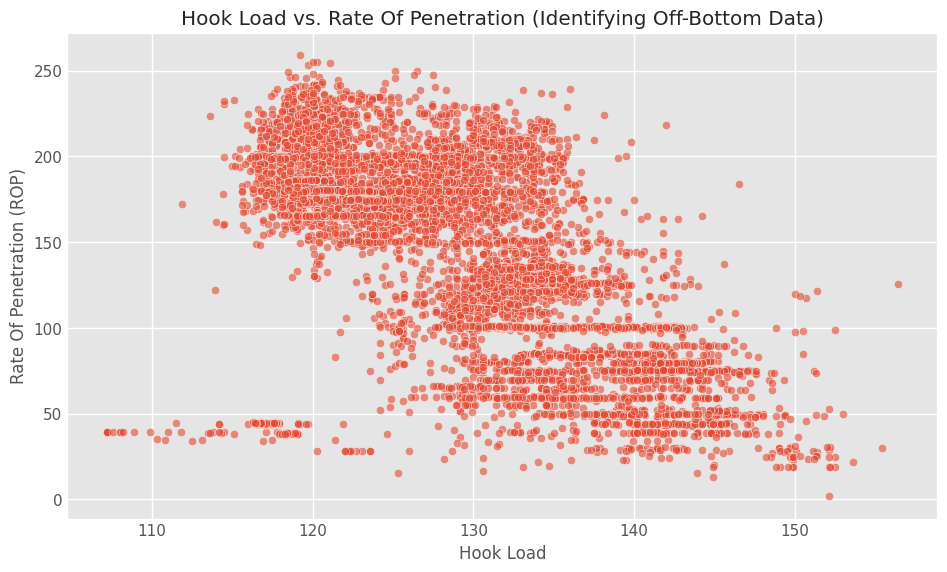

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Hook Load', y='Rate Of Penetration', data=data, alpha=0.6)
plt.title('Hook Load vs. Rate Of Penetration (Identifying Off-Bottom Data)')
plt.xlabel('Hook Load')
plt.ylabel('Rate Of Penetration (ROP)')
plt.grid(True)
plt.show()


### EDA Insight from the Scatter Plot: Identifying "Off-Bottom" Noise

The scatter plot of `Hook Load` versus `Rate Of Penetration` is a powerful tool for identifying data points where the drill bit is not actively engaged with the rock, often referred to as "off-bottom" conditions.

**Visual Interpretation:**

Upon examining the scatter plot, you should observe a distinct cluster of data points (or a dense line of points) characterized by:

*   **Near-zero `Rate Of Penetration` (ROP)**: These points will be concentrated along or very close to the x-axis, indicating that no significant drilling is occurring.
*   **High `Hook Load`**: Simultaneously, these same points will correspond to the upper range of `Hook Load` values. This is because when the bit is off-bottom, the entire weight of the drill string is suspended by the rig's hoisting system, resulting in a high `Hook Load` reading.

This cluster represents the "tripping" or "circulating" phase of the drilling operation, where the drill string is being lowered or raised, or fluids are being circulated without actual drilling. During these phases, ROP is (or should be) zero.

**Why this Insight Matters for Data Cleaning and Model Accuracy:**

This visual proof from the EDA is critically important for the integrity of our machine learning model for several reasons:

1.  **Preventing Misleading Correlations**: If we were to include these "off-bottom" data points in our training set, the ML model would learn a physically incorrect relationship. It would observe many instances where a high `Hook Load` is associated with a zero `ROP`. The model might erroneously conclude that high `Hook Load` *causes* low or zero ROP, which is the opposite of how drilling typically works (where `Weight on Bit`, derived from `Hook Load` and drill string weight, is used to increase ROP).

2.  **Focusing on "On-Bottom" Dynamics**: Our primary goal is to predict ROP when the bit is actively drilling. "Off-bottom" data represents non-drilling activities. By filtering these data points, we ensure that our model focuses solely on the physics of rock-bit interaction and learns meaningful relationships between drilling parameters and ROP under actual drilling conditions.

3.  **Improving Model Performance**: Training on relevant data leads to better model performance. Eliminating the "off-bottom" noise reduces the variance and complexity in the training data, allowing the model to more accurately capture the true patterns that govern ROP during active drilling. This directly contributes to higher predictive accuracy and more reliable insights.

**Actionable Step**: This EDA insight clearly demonstrates the necessity of filtering the dataset to include only "on-bottom" data points. This typically involves defining a threshold for `Rate Of Penetration` (e.g., ROP > 0 or ROP > a minimal threshold) and potentially other parameters like `Weight on Bit` to isolate the actual drilling periods.

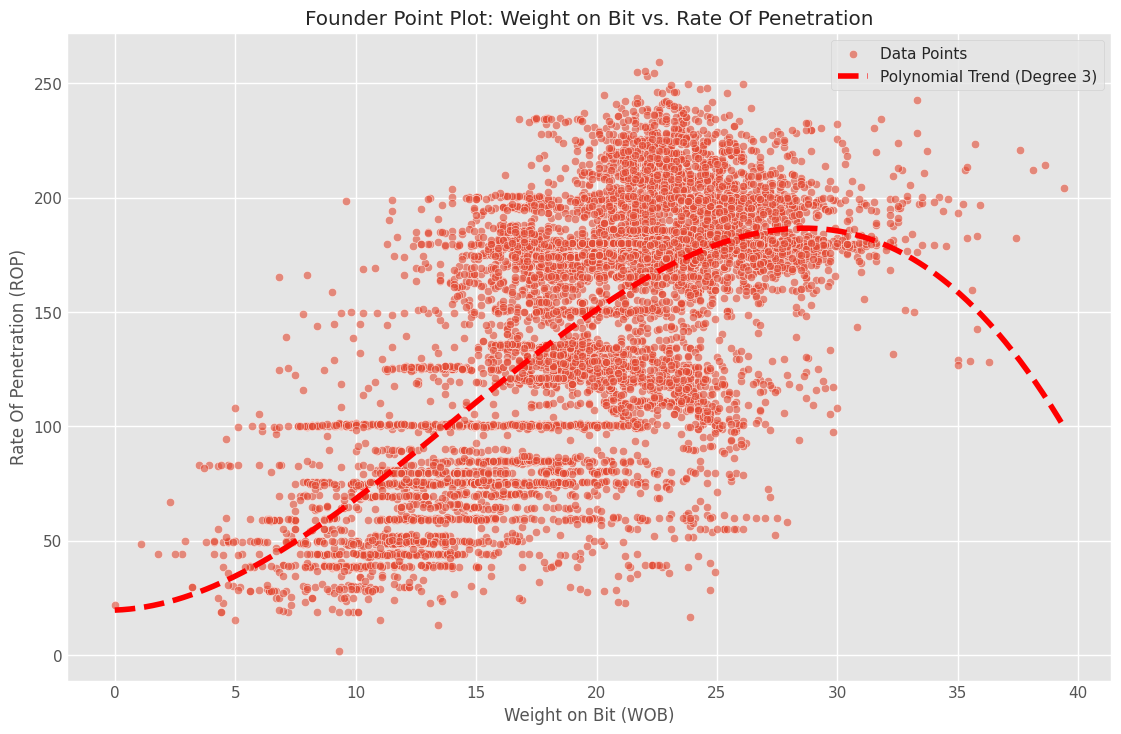

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

plt.figure(figsize=(12, 8))
sns.scatterplot(x='Weight on Bit', y='Rate Of Penetration', data=data, alpha=0.6, label='Data Points')

# Create a polynomial regression model
degree = 3 # A cubic polynomial might capture the curve (up, flat, drop)
poly_model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

# Fit the model to the data
X_wob = data['Weight on Bit'].values.reshape(-1, 1)
y_rop = data['Rate Of Penetration'].values
poly_model.fit(X_wob, y_rop)

# Generate predictions for the trend line
wob_range = np.linspace(X_wob.min(), X_wob.max(), 500).reshape(-1, 1)
rop_pred = poly_model.predict(wob_range)

sns.lineplot(x=wob_range.flatten(), y=rop_pred, color='red', linestyle='--', label=f'Polynomial Trend (Degree {degree})')

plt.title('Founder Point Plot: Weight on Bit vs. Rate Of Penetration')
plt.xlabel('Weight on Bit (WOB)')
plt.ylabel('Rate Of Penetration (ROP)')
plt.grid(True)
plt.legend()
plt.show()


### EDA Insight from the Scatter Plot: Bit Foundering & The "Drilling Window"

This scatter plot, augmented with a polynomial regression trend line, visually demonstrates a critical drilling phenomenon known as 'Bit Foundering' or 'Bit Balling'. This insight is paramount for understanding the non-linear nature of drilling and for guiding the selection of appropriate machine learning models.

**Visual Interpretation:**

Upon examining the plot of `Weight on Bit` (WOB) versus `Rate Of Penetration` (ROP), you should observe the following characteristic curve in the trend line:

1.  **Initial Increase (Linear Phase)**: As `Weight on Bit` increases from lower values, the `Rate Of Penetration` (ROP) also **increases**. This is the desirable part of the 'drilling window', where applying more force effectively translates into faster drilling. This is represented by a straight, upward-sloping line in this zone, indicating efficient drilling.
2.  **Flattening Phase**: Beyond a certain point, the increase in ROP starts to **slow down** or flatten out, even as WOB continues to increase. This indicates that the bit is approaching its optimal drilling capacity for the given formation.
3.  **Peak (The Founder Point)**: Critically, the curve eventually reaches a **peak ROP**. This represents the maximum amount of weight the bit can handle while still clearing away the rock chips effectively. This is often referred to as the 'Founder Point'.
4.  **Drop (Efficiency Drop/Foundering/Balling)**: Past the founder point, the ROP starts to **drop**, even as WOB continues to be applied or increased. This is the 'foundering' or 'bit balling' region. In this phase, adding more weight no longer increases speed; instead, it causes problems like bit balling, vibrations, or poor hole cleaning, leading to a *decrease* in ROP despite higher WOB.

**Why this Insight Matters for Model Selection:**

This distinct curvilinear relationship has profound implications for our predictive modeling:

1.  **Invalidating Simple Linear Regression**: A simple linear regression model assumes a constant, straight-line relationship between WOB and ROP. This plot clearly shows that such a model would utterly fail to capture the optimal drilling point or the foundering effect. It would either underestimate ROP at optimal WOB or incorrectly suggest that more WOB always yields more ROP, leading to suboptimal drilling recommendations.

2.  **Necessity of Non-Linear Models**: The observed curve unequivocally proves the need for more complex, non-linear machine learning models. Algorithms like:
    *   **Random Forest Regressor**
    *   **Gradient Boosting Regressor**
    *   **Support Vector Regressor (with non-linear kernels)**
    *   **Neural Networks (like `MLPRegressor`)**

    These models are capable of learning and approximating such complex, non-linear relationships, including the turning point where increasing WOB becomes detrimental to ROP. They can capture the 'Optimization Peak' and provide more accurate predictions across the entire range of WOB values.

3.  **Practical Drilling Optimization**: Understanding this curve is vital for drillers. It allows them to identify the optimal WOB range for maximizing ROP while avoiding foundering, thereby increasing drilling efficiency, reducing bit wear, and preventing potential drill string damage.

In conclusion, this EDA step is not just about data visualization; it's a foundational 'proof' that guides our choice of advanced machine learning techniques capable of handling the intricate, non-linear physics of the drilling process.

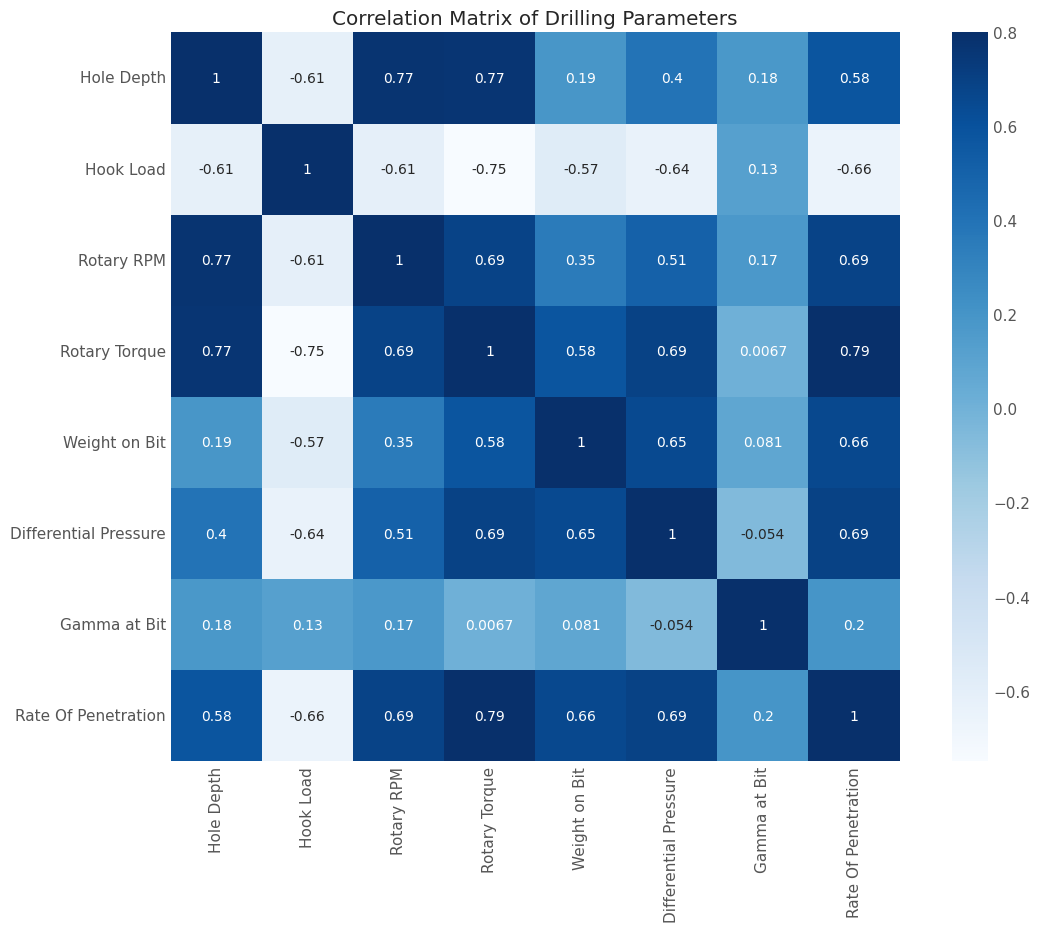

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corrmat = data.corr()

f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True,cmap="Blues",annot=True,cbar=True)
plt.title('Correlation Matrix of Drilling Parameters')
plt.show()


### Analysis of the Correlation Matrix: Drilling Signatures

The heatmap above visually represents the correlation matrix of all drilling parameters. This matrix is essential for understanding the linear relationships between the variables and identifying the 'Drilling Signatures' we discussed earlier.

Let's analyze the key correlations:

1.  **WOB vs. ROP (Weight on Bit vs. Rate Of Penetration)**:
    *   **Observation**: Look at the correlation coefficient between `Weight on Bit` and `Rate Of Penetration`. A strong **positive correlation** is expected here. This signifies that as `Weight on Bit` increases, `Rate Of Penetration` also tends to increase. This is the fundamental 'drilling window' relationship, indicating that applying more downward force generally leads to faster drilling. If this correlation were weak or negative, it would immediately signal inefficiencies like bit balling or foundering.

2.  **RPM vs. Torque (Rotary RPM vs. Rotary Torque)**:
    *   **Observation**: Examine the correlation between `Rotary RPM` and `Rotary Torque`. We anticipate a **positive correlation**. Higher rotational speed typically demands more torque to maintain that speed, especially when interacting with the formation. A deviation, such as a strong torque reading without a corresponding increase in RPM, could indicate tougher formations or stick-slip.

3.  **Differential Pressure vs. ROP (Differential Pressure vs. Rate Of Penetration)**:
    *   **Observation**: Check the correlation between `Differential Pressure` and `Rate Of Penetration`. In motor drilling, `Differential Pressure` is often a proxy for the actual torque at the bit. Therefore, a **strong positive correlation** here would confirm that the downhole motor is efficiently translating pressure into the work needed for penetration. If this correlation is weak, it might suggest motor performance issues or other mechanical inefficiencies.

4.  **Depth vs. ROP (Hole Depth vs. Rate Of Penetration)**:
    *   **Observation**: Look at the correlation between `Hole Depth` and `Rate Of Penetration`. A **negative correlation** is commonly observed. As `Hole Depth` increases, the rock formations generally become more compacted and harder to drill, which naturally leads to a decrease in `ROP`. A weak or positive correlation might indicate drilling through unusually soft deeper formations, or highly effective drilling optimization techniques offsetting the depth effect.

**Overall Interpretation**:

The correlation matrix provides a quick and powerful overview of how changes in one drilling parameter are associated with changes in others. It helps in validating expected drilling physics and in pinpointing relationships that might warrant further investigation due to unexpected strength or weakness, hinting at operational issues or unique geological conditions.


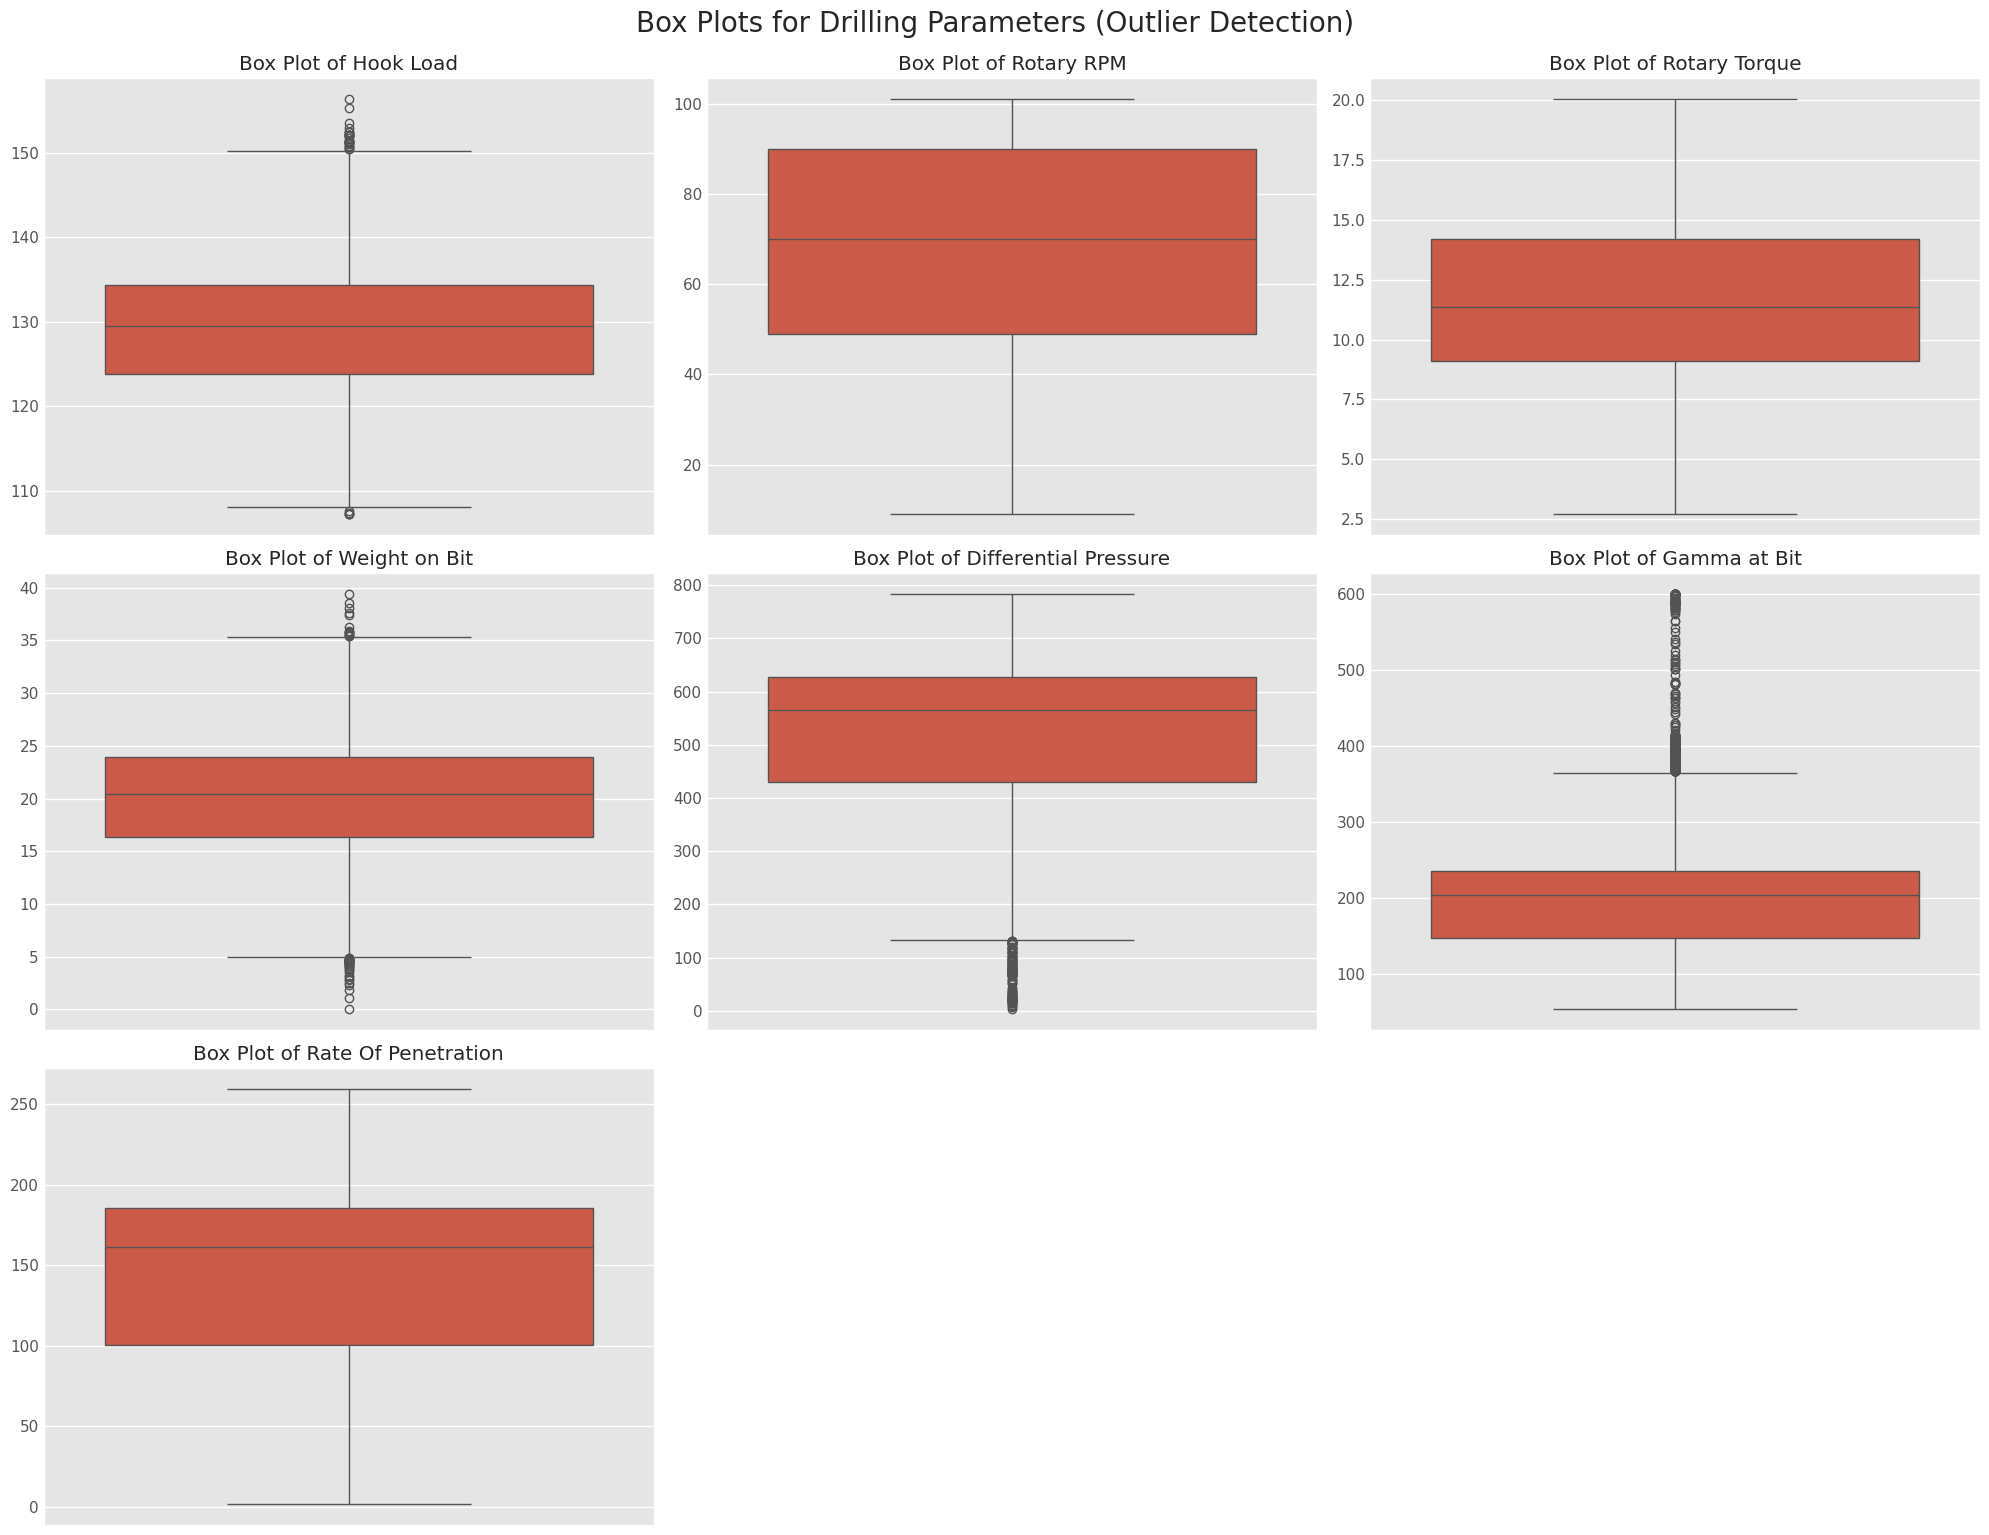

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all numerical columns (excluding 'Hole Depth' as its range is very different and would skew visualization)
# We'll also exclude 'Hole Depth' for individual box plots as its magnitude is much larger
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()

# Remove 'Hole Depth' from the list for individual box plots if it's there
if 'Hole Depth' in numerical_cols:
    numerical_cols.remove('Hole Depth')

# Create box plots for each numerical parameter
plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of features
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('') # Remove y-label as it's repetitive
plt.tight_layout()
plt.suptitle('Box Plots for Drilling Parameters (Outlier Detection)', y=1.02, fontsize=20)
plt.show()


### EDA Insight from Box Plots: Identifying "Drilling Dysfunction" Outliers

The box plots generated for each drilling parameter serve as a powerful visual tool for 'Outlier Detection', which in the context of drilling, often translates to identifying 'Drilling Dysfunctions'.

**Visual Interpretation:**

For each box plot, you'll observe:

*   **The Box**: Represents the interquartile range (IQR), containing the middle 50% of the data. The line inside the box is the median.
*   **The Whiskers**: Extend from the box to show the range of typical data, usually 1.5 times the IQR. Anything beyond these whiskers is considered an outlier.
*   **The "Dots" (Outliers)**: These are individual data points plotted far outside the whiskers. These "dots" are particularly important in drilling data.

**What the "Dots" (Outliers) Signify in Drilling:**

In drilling operations, these outliers are rarely mere data entry errors. Instead, they frequently represent real-world physical events, often indicative of 'Drilling Dysfunctions' such as:

*   **Stick-Slip Vibrations**: Characterized by sudden, large fluctuations in `Rotary Torque` and `Rotary RPM`. The drill bit momentarily sticks in the formation, then rapidly slips forward, leading to severe torsional vibrations. These would appear as significant spikes in `Rotary Torque`.
*   **Whirl**: A dynamic instability where the drill bit precesses around the borehole, leading to eccentric wear and increased lateral vibrations. This can manifest as unusual `Rotary RPM` or `Weight on Bit` readings.
*   **Bit Balling**: When sticky formation cuttings (e.g., clay-rich shales) accumulate on the bit face, severely reducing its cutting efficiency. This would likely cause `ROP` to drop significantly despite high `Weight on Bit` and `Rotary RPM`, and could lead to `Rotary Torque` spikes.
*   **Hard Stringers/Breakthroughs**: Abrupt changes in `ROP`, `Rotary Torque`, or `Differential Pressure` when the bit encounters an unexpectedly hard layer or breaks through into a softer one.
*   **Sensor Errors/Spikes**: While less common, extreme, isolated spikes might still be sensor malfunctions. However, in the context of physical parameters, most are operational.

**Why it Matters: The Data Cleaning vs. Dysfunction Detection Dilemma:**

This EDA insight presents a critical decision point for our machine learning model:

1.  **Option 1: Delete Outliers for a "Clean" Model**: If our primary goal is to predict ROP under *normal, efficient drilling conditions*, then removing these outliers would create a

### Defining Target Variable (y) and Feature Matrix (X)

As established by the analysis, the 'Rate Of Penetration' (ROP) is our target variable for predictive modeling. The remaining drilling parameters will serve as our input features. I will now explicitly define `y` as ROP and `X` as the feature matrix.

In [ ]:
data.columns
data.shape

(7934, 8)

In [62]:

y=data.iloc[:,-1].values
y

array([ 34.29,  34.04,  34.17, ..., 198.56, 198.56, 185.07])

In [63]:
X=data.iloc[:,:-1]
#X.shape
X

,Hole Depth,Hook Load,Rotary RPM,Rotary Torque,Weight on Bit,Differential Pressure,Gamma at Bit
0,6524,117.5,29,6.702,15.6,370.6,134.12
1,6525,116.9,29,4.345,10.2,202.9,136.47
2,6526,112.5,29,5.151,10.2,359.0,134.12
3,6527,113.1,29,5.016,9.4,332.6,138.82
4,6528,110.8,29,5.510,10.6,343.7,141.18
...,...,...,...,...,...,...,...
7929,14450,118.3,100,17.131,24.2,649.5,225.88
7930,14451,118.6,100,16.165,23.5,648.3,223.53
7931,14452,118.3,100,16.528,23.8,646.6,223.53
7932,14453,118.0,100,15.854,23.8,662.9,225.88


"Leveraging Partial Dependence Plots to Elucidate Key Determinants of Rate of Penetration (ROP)."

This phrasing emphasizes the analytical technique, the outcome, and uses more formal language.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import partial_dependence, PartialDependenceDisplay
from sklearn.preprocessing import MinMaxScaler

In [ ]:
X.columns

Index(['Hole Depth', 'Hook Load', 'Rotary RPM', 'Rotary Torque',
       'Weight on Bit', 'Differential Pressure', 'Gamma at Bit'],
      dtype='object')

Test R2 score: 0.78


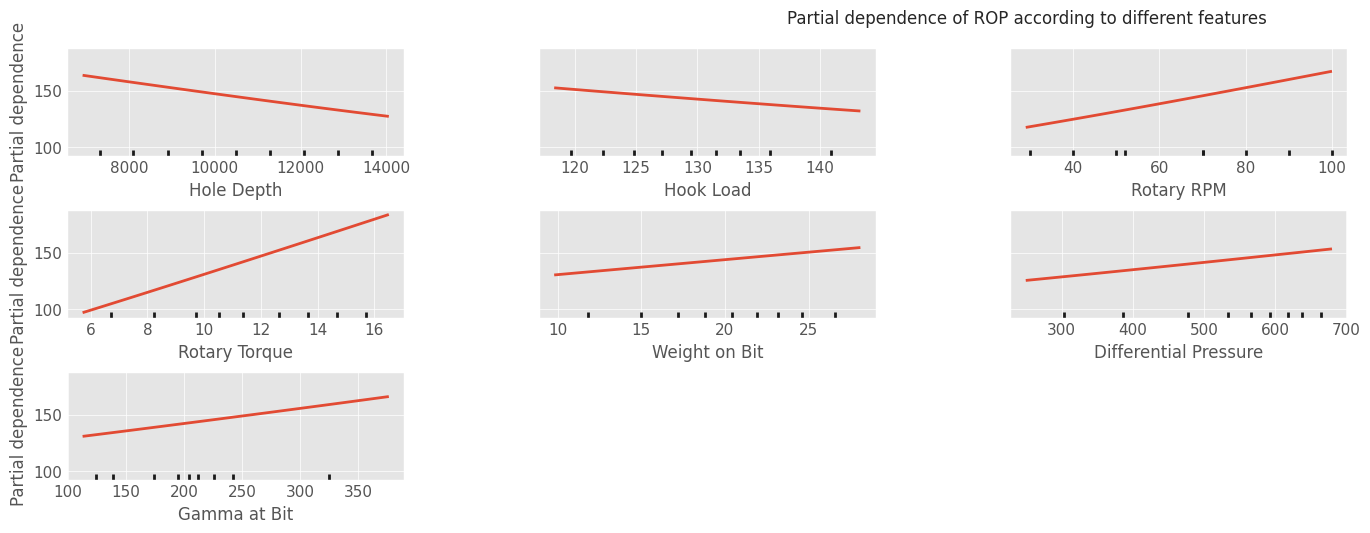

In [ ]:
plt.style.use('ggplot')
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size
=0.25)
model=make_pipeline(MinMaxScaler(), MLPRegressor(hidden_layer_sizes=(25,25),
                                 learning_rate_init=0.01,
                                 early_stopping=True,max_iter=1000))
model.fit(X_train, y_train)
print("Test R2 score: {:.2f}".format(model.score(X_test, y_test)))
features=['Hole Depth', 'Hook Load', 'Rotary RPM', 'Rotary Torque',
       'Weight on Bit', 'Differential Pressure', 'Gamma at Bit']

# Use PartialDependenceDisplay.from_estimator for plotting partial dependence
# Pass the feature names directly from X.columns if X is a DataFrame
# Or create a list of feature names if X is a numpy array

# Assuming X is still a DataFrame with column names
disp = PartialDependenceDisplay.from_estimator(model, X, features,
                                                 n_jobs=3, grid_resolution=20)
disp.figure_.suptitle('Partial dependence of ROP according to different features')
disp.figure_.subplots_adjust(hspace=.5,wspace=.4 ,top=.9,bottom=0,right=1,left=-1)
plt.show()

### Predictive Model Training and Partial Dependence Analysis

This section outlines the setup and initial training of a predictive model for Rate of Penetration (ROP), followed by a crucial step in model interpretability: the generation of Partial Dependence Plots (PDPs).

**1. Data Preparation and Model Initialization:**
*   **Data Splitting**: The dataset is first partitioned into training and testing sets (`X_train, X_test, y_train, y_test`) using `train_test_split` with a `test_size` of 0.25. This ensures that the model's performance can be evaluated on unseen data, providing an unbiased estimate of its generalization capability.
*   **Feature Scaling**: A `MinMaxScaler` is integrated into the `make_pipeline`. This step is critical as `MLPRegressor` (and many other machine learning algorithms) are sensitive to the scale of input features. Normalizing features to a common range prevents features with larger numerical values from dominating the learning process.
*   **Model Architecture**: An `MLPRegressor` is chosen, configured with two hidden layers, each containing 25 neurons (`hidden_layer_sizes=(25,25)`). The `learning_rate_init` is set to 0.01, and `early_stopping` is enabled to prevent overfitting by monitoring performance on a validation set (implicitly created by `early_stopping`). `max_iter` is set to 1000 to define the maximum number of training iterations.

**2. Model Training and Initial Evaluation:**
*   The `model` pipeline is fitted to the training data (`X_train, y_train`). During this phase, the MLPRegressor learns the complex, non-linear relationships between the input features and the target ROP.
*   The `R2 score` is then calculated and printed for the test set. This metric, representing the proportion of variance in the dependent variable that can be predicted from the independent variables, provides a quantitative measure of how well the model generalizes to new data. An R2 score of 0.78 indicates that 78% of the variance in ROP can be explained by the model's features.

**3. Partial Dependence Plot (PDP) Generation:**
*   **Purpose**: Partial Dependence Plots (PDPs) are powerful tools for interpreting the behavior of complex machine learning models. They illustrate the marginal effect of one or two features on the predicted outcome of a model, while accounting for the average effect of all other features.
*   **Implementation**: `PartialDependenceDisplay.from_estimator` is utilized to generate individual PDPs for each input feature. The `grid_resolution` parameter controls the number of points at which the partial dependence is evaluated, and `n_jobs` leverages parallel processing for faster computation.
*   **Visualization**: The generated plots visually depict how changes in individual features influence the predicted ROP, averaged over the values of other features. This allows for the identification of linear, non-linear, or monotonic relationships between each feature and ROP, offering insights into the model's decision-making process that complement basic correlation analysis.

**Significance in EDA:**
This process seamlessly integrates predictive modeling with exploratory data analysis. While traditional EDA techniques like correlation matrices and pairplots reveal inherent data relationships, PDPs go a step further by exposing how the *trained model perceives* these relationships. This is invaluable for:
*   **Model Understanding**: Gaining insights into which features drive the model's predictions and how.
*   **Feature Engineering**: Identifying potential non-linear interactions or thresholds that could inform the creation of new, more effective features.
*   **Domain Validation**: Comparing the model's learned dependencies with existing domain knowledge to validate its plausibility or uncover new phenomena.

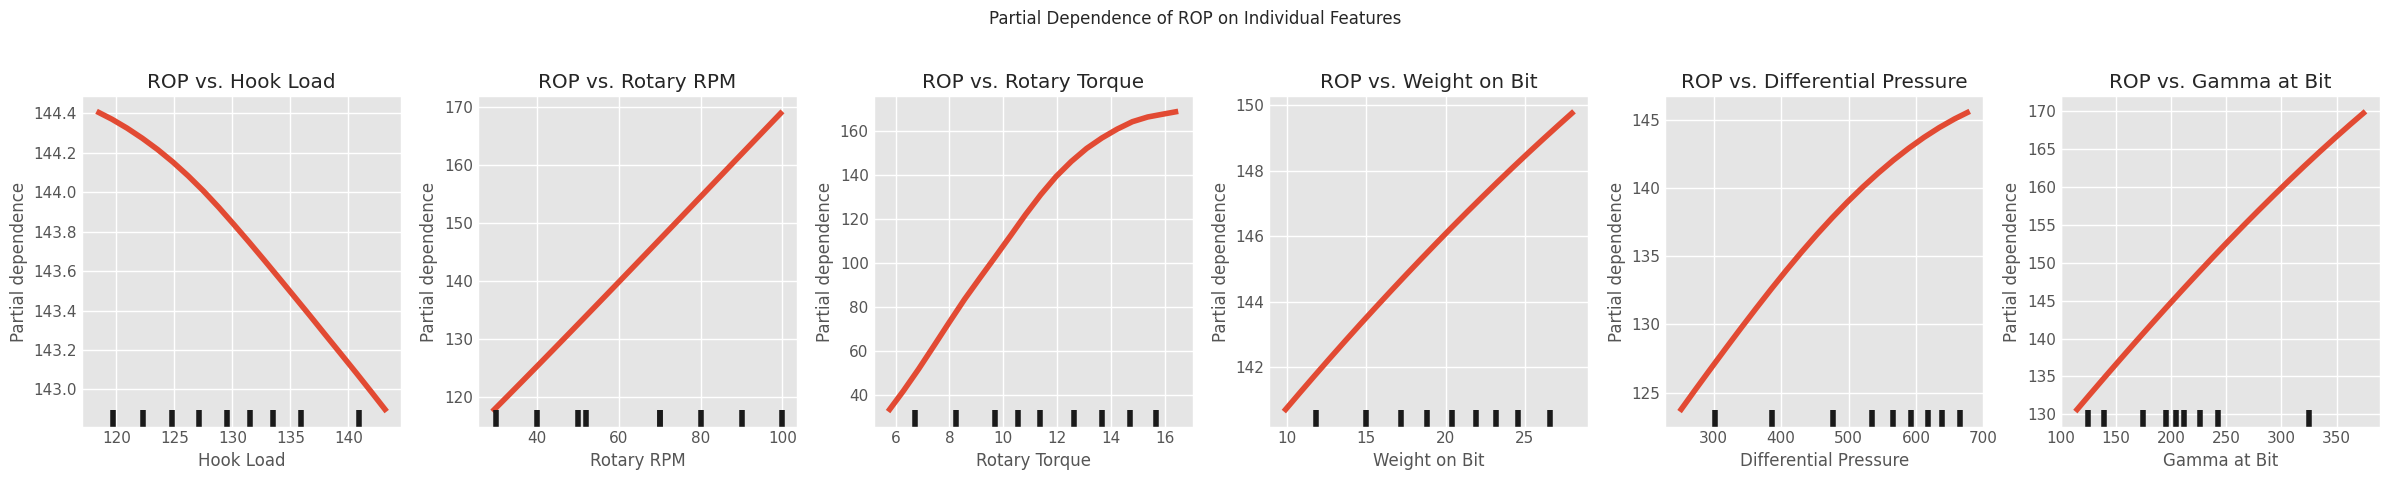

In [ ]:
imp_features=['Hook Load', 'Rotary RPM', 'Rotary Torque','Weight on Bit', 'Differential Pressure', 'Gamma at Bit']

# When plotting multiple features, use a list of tuples for interactions or individual strings for single features
# For individual plots, loop through the features
fig, ax = plt.subplots(ncols=len(imp_features), figsize=(4 * len(imp_features), 5))
for i, feature in enumerate(imp_features):
    PartialDependenceDisplay.from_estimator(model, X, [feature],
                                           ax=ax[i], n_jobs=3, grid_resolution=20)
    ax[i].set_title(f'ROP vs. {feature}')

fig.suptitle('Partial Dependence of ROP on Individual Features')
fig.subplots_adjust(hspace=0.6, wspace=0.5, top=0.8, bottom=0.1, right=0.9, left=0.1)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

from the partial dependance plot we can see that Rotary torue ,Rotary RPM ,Hook load ,DP ,WOB
are important features for predicting ROP

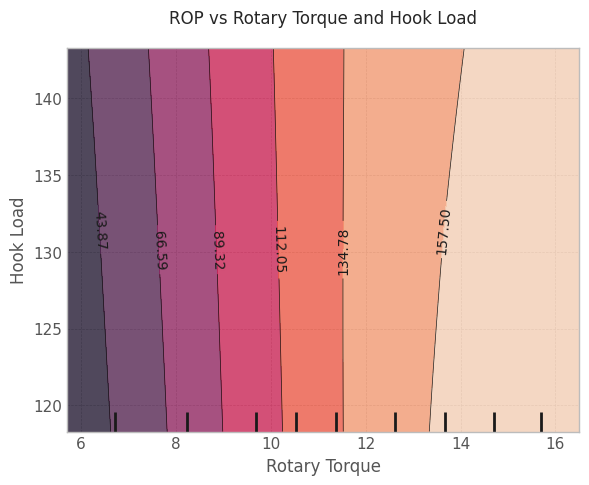

In [ ]:
plt.style.use('bmh')

imp_features=[('Rotary Torque','Hook Load')]
disp = PartialDependenceDisplay.from_estimator(model, X, imp_features, n_jobs=3,
                                                grid_resolution=20)
disp.figure_.suptitle('ROP vs Rotary Torque and Hook Load')
disp.figure_.subplots_adjust(hspace=0.6, wspace=0.5, top=0.9, bottom=0.1, right=0.9, left=0.1)
plt.show()

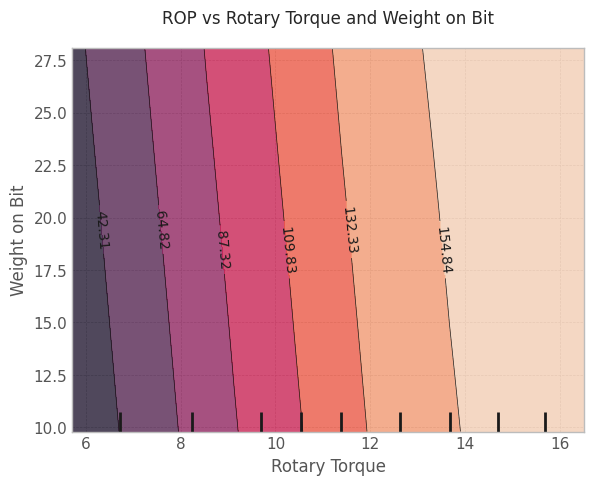

In [ ]:
plt.style.use('bmh')

imp_features=[('Rotary Torque','Weight on Bit')]
disp = PartialDependenceDisplay.from_estimator(model, X, imp_features, n_jobs=3,
                                                grid_resolution=20)
disp.figure_.suptitle('ROP vs Rotary Torque and Weight on Bit')
disp.figure_.subplots_adjust(hspace=0.6, wspace=0.5, top=0.9, bottom=0.1, right=0.9, left=0.1)
plt.show()

### Analysis of Two-Dimensional Partial Dependence Plots: Feature Interactions

The two-dimensional Partial Dependence Plots (PDPs) generated for (`Rotary Torque`, `Hook Load`) and (`Rotary Torque`, `Weight on Bit`) provide critical insights into how the interaction of these feature pairs influences the predicted Rate of Penetration (ROP).

**Key Interpretation of 2D PDPs:**

Unlike individual PDPs, which show the marginal effect of a single feature, 2D PDPs illustrate the combined effect of two features on the prediction. This allows us to detect potential synergies or antagonistic relationships between drilling parameters that would not be apparent from univariate analysis.

#### 1. ROP vs. Rotary Torque and Hook Load

*   **Visual Representation**: This plot will show a surface where the x-axis represents `Rotary Torque`, the y-axis represents `Hook Load`, and the color gradient (or z-axis for 3D plots) indicates the predicted ROP.
*   **Expected Trends**:
    *   **Rotary Torque**: Based on the Spearman correlation, increasing `Rotary Torque` generally correlates with higher ROP. The PDP should visually confirm this, with ROP tending to increase as `Rotary Torque` moves towards higher values.
    *   **Hook Load**: `Hook Load` showed a strong negative monotonic relationship with ROP. This PDP should likely show a decrease in ROP as `Hook Load` increases, especially when `Rotary Torque` is lower.
*   **Interaction Insights**:
    *   We can observe if the effect of `Rotary Torque` on ROP changes significantly at different levels of `Hook Load`. For example, a high `Rotary Torque` might lead to a high ROP across all `Hook Load` values, or its effectiveness might be diminished/enhanced depending on the `Hook Load` level.
    *   Conversely, we can see if varying `Hook Load` has a different impact on ROP when `Rotary Torque` is low versus when it is high.
    *   This plot can help identify operational zones where a balance between `Rotary Torque` (reflecting rock resistance and bit engagement) and `Hook Load` (indicating overall drill string weight and drag) leads to optimal ROP.

#### 2. ROP vs. Rotary Torque and Weight on Bit

*   **Visual Representation**: Similar to the previous plot, this surface will display `Rotary Torque` on one axis, `Weight on Bit` on the other, and predicted ROP as the response.
*   **Expected Trends**:
    *   **Rotary Torque**: As with the prior PDP, increasing `Rotary Torque` is expected to show an increase in ROP.
    *   **Weight on Bit**: `Weight on Bit` (WOB) also exhibited a strong positive monotonic relationship with ROP. Therefore, we should see ROP increasing as WOB increases.
*   **Interaction Insights**:
    *   This is a critical interaction as both `Rotary Torque` and `Weight on Bit` are primary drivers of penetration. The plot will reveal if there's a synergistic effect, meaning that high `Rotary Torque` *and* high `Weight on Bit` combine to produce ROP significantly higher than the sum of their individual effects.
    *   We can also identify if there's a 'sweet spot' or an optimal combination of `Rotary Torque` and `Weight on Bit` that maximizes ROP. For instance, too much WOB might lead to bit balling (reducing ROP) if `Rotary Torque` is insufficient to clear cuttings, or vice versa.
    *   The contour lines or color gradients can highlight regions where the bit is most aggressive and effective for different combinations of these two parameters. This provides practical guidelines for drillers to adjust WOB and `Rotary Torque` simultaneously.

**Overall Significance:**

These 2D PDPs are invaluable for understanding the complex interplay between drilling parameters. They move beyond simple correlations to show how the `MLPRegressor` model combines the influence of these features to predict ROP. Such insights are crucial for developing sophisticated drilling optimization strategies, allowing for real-time adjustments that maximize efficiency and maintain wellbore stability.

Standard scaling

### 4. Feature Engineering & Scaling Logic: Understanding the Math Behind Preprocessing

In machine learning, the scale of input features can significantly impact the performance and interpretability of models. Features measured in different units or ranges can lead to biases in the learning process, particularly for algorithms that rely on distance calculations or gradient descent optimization.

#### Why Scaling is Essential for Drilling Data

Consider our drilling dataset, where 'Hole Depth' is measured in thousands of feet (e.g., 6,000 to 14,000) and 'Differential Pressure' is in hundreds of psi (e.g., 200 to 800). If we were to feed these raw values directly into a Machine Learning model without scaling, features with larger numerical magnitudes, like 'Hole Depth', would inherently have a disproportionately larger influence on the model's cost function and parameter updates compared to features with smaller ranges, such as 'Rotary RPM' (e.g., 10 to 100).

This phenomenon is particularly problematic for:

*   **Distance-based algorithms**: Algorithms like K-Nearest Neighbors (KNN), Support Vector Machines (SVMs), and K-Means clustering calculate distances between data points. If 'Hole Depth' has values 100 times larger than 'Rotary RPM', a small change in 'Hole Depth' would appear to be a much larger difference in the feature space than a significant change in 'Rotary RPM', regardless of their actual importance.
*   **Gradient-descent-based algorithms**: Models such as Linear Regression, Logistic Regression, and Neural Networks (like our `MLPRegressor`) optimize their parameters using gradient descent. If features are on vastly different scales, the gradients for parameters associated with larger-scaled features will also be larger. This can lead to slow convergence, oscillations, or the algorithm getting stuck in suboptimal local minima, as the optimization process will prioritize adjusting the weights of the features with larger magnitudes.

#### How Scaling Prevents 'Over-Weighting'

Scaling transforms the feature values so that they fall within a similar range or have similar statistical properties. This ensures that the model treats each physical input with the correct mathematical weight, preventing features from dominating simply due to their arbitrary unit of measurement. The goal is to bring all features to a common scale without distorting differences in the ranges of values or losing information.

Two common scaling methods are:

1.  **StandardScaler (Z-score Normalization)**:
    *   **Math**: For each feature $x$, the scaled value $x'$ is calculated as:
        $x' = \frac{x - \mu}{\sigma}$
        where $\mu$ is the mean of the feature and $\sigma$ is its standard deviation.
    *   **Effect**: This transformation scales the data such that it has a mean of 0 and a standard deviation of 1. It is useful when features have different scales and the algorithm assumes normally distributed data or is sensitive to feature variance.

2.  **MinMaxScaler (Min-Max Scaling)**:
    *   **Math**: For each feature $x$, the scaled value $x'$ is calculated as:
        $x' = \frac{x - \min(x)}{\max(x) - \min(x)}$
        where $\min(x)$ is the minimum value of the feature and $\max(x)$ is its maximum value.
    *   **Effect**: This transformation scales the data to a fixed range, typically `[0, 1]`. It is effective when the dataset contains outliers and is preferred for algorithms that expect input features in a specific range (e.g., neural networks with sigmoid activation functions).

By applying either `StandardScaler` or `MinMaxScaler`, we ensure that each feature contributes proportionally to the model's learning process. For example, a change of 1 standard deviation in 'Hole Depth' will have the same relative impact as a change of 1 standard deviation in 'Differential Pressure' on the model, even though their original numerical ranges were vastly different. This allows the model to learn the true underlying relationships between the features and ROP, rather than being skewed by the arbitrary scales of the raw data.

In [ ]:

#Standard Scaler for Data

scaler = StandardScaler(copy=True, with_mean=True, with_std=True)
X = scaler.fit_transform(X)

#showing data
print('X \n' , X[:10])
print('y \n' , y[:10])


X 
 [[-1.73110307 -1.57589241 -1.5223347  -1.40495509 -0.75324064 -1.05044014
  -0.95255174]
 [-1.73066635 -1.65357292 -1.5223347  -2.10096241 -1.71556193 -2.22753902
  -0.92372862]
 [-1.73022964 -2.22322996 -1.5223347  -1.86295566 -1.71556193 -1.13186141
  -0.95255174]
 [-1.72979293 -2.14554945 -1.5223347  -1.90282032 -1.85812805 -1.31716499
  -0.8949055 ]
 [-1.72935621 -2.44332472 -1.5223347  -1.75694522 -1.64427887 -1.23925326
  -0.86595973]
 [-1.7289195  -2.50805847 -1.5223347  -1.91935677 -1.55517505 -0.96901887
  -0.92372862]
 [-1.72848278 -2.55984548 -1.5223347  -1.72269114 -1.18093899 -1.08062216
  -0.86595973]
 [-1.72804607 -2.896461   -1.5223347  -1.69818176 -1.0740144  -1.10167939
  -0.86595973]
 [-1.72760936 -2.90940775 -1.5223347  -1.70704058 -1.05619364 -0.86022321
  -0.86595973]
 [-1.72717264 -2.90940775 -1.5223347  -1.76668991 -1.10965593 -1.09185268
  -0.86595973]]
y 
 [34.29 34.04 34.17 34.48 34.31 34.86 39.2  39.12 39.16 39.21]


In [ ]:
#Splitting data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=44, shuffle =True)

#Splitted Data
#print('X_train shape is ' , X_train.shape)
#print('X_test shape is ' , X_test.shape)
#print('y_train shape is ' , y_train.shape)
#print('y_test shape is ' , y_test.shape)

In [ ]:
#Applying Linear Regression Model

LinearRegressionModel= LinearRegression(fit_intercept=True, normalize=True,copy_X=True,n_jobs=-1)
LinearRegressionModel.fit(X_train, y_train)

#Calculating Details
#print('Linear Regression Train Score is : ' , LinearRegressionModel.score(X_train, y_train))
#print('Linear Regression Test Score is : ' , LinearRegressionModel.score(X_test, y_test))
#print('Linear Regression Coef is : ' , LinearRegressionModel.coef_)
#print('Linear Regression intercept is : ' , LinearRegressionModel.intercept_)

score_LRM =LinearRegressionModel.score(X_test, y_test)


#print(score_LRM)
#Calculating Prediction
y_pred = LinearRegressionModel.predict(X_test)
#print('Predicted Value for Linear Regression is : ' , y_pred[:10])
#Calculating Mean Absolute Error

MAEValue_LRM = mean_absolute_error(y_test, y_pred, multioutput='uniform_average') # it can be raw_values

#print('Mean Absolute Error Value is : ', MAEValue_LRM)


/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_base.py:145: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), LinearRegression())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)


  FutureWarning,


In [ ]:
#Applying SGDRegressor Model

'''
sklearn.linear_model.SGDRegressor(loss='squared_loss’, penalty=’l2’, alpha=0.0001,
                                  l1_ratio=0.15, fit_intercept=True, max_iter=None,
                                  tol=None, shuffle=True, verbose=0, epsilon=0.1,
                                  random_state=None, learning_rate='invscaling’,
                                  eta0=0.01, power_t=0.25, early_stopping=False,
                                  validation_fraction=0.1, n_iter_no_change=5,
                                  warm_start=False, average=False, n_iter=None)
'''

SGDRegressionModel = SGDRegressor(alpha=.0001,random_state=33,penalty='l2',max_iter=1000)
SGDRegressionModel.fit(X_train, y_train)

#Calculating Details
#print('SGD Regression Train Score is : ' , SGDRegressionModel.score(X_train, y_train))
#print('SGD Regression Test Score is : ' , SGDRegressionModel.score(X_test, y_test))
#print('SGD Regression Coef is : ' , SGDRegressionModel.coef_)
#print('SGD Regression intercept is : ' , SGDRegressionModel.intercept_)
#print('----------------------------------------------------')

score_SGD=SGDRegressionModel.score(X_test, y_test)
#Calculating Prediction
y_pred = SGDRegressionModel.predict(X_test)
#print('Predicted Value for SGD Regression is : ' , y_pred[:10])


#Calculating Mean Absolute Error

MAEValue_SGD = mean_absolute_error(y_test, y_pred, multioutput='uniform_average') # it can be raw_values

#print('Mean Absolute Error Value is : ', MAEValue_LRM)

In [ ]:
#Applying Lasso Regression Model

'''
sklearn.linear_model.Lasso(alpha=1.0, fit_intercept=True, normalize=False, precompute=
                           False, copy_X=True, max_iter=1000, tol=0.0001,
                           warm_start=False, positive=False, random_state=None,selection='cyclic')
'''

LassoRegressionModel = Lasso(alpha=.0001,random_state=33,normalize=True)
LassoRegressionModel.fit(X_train, y_train)

#Calculating Details
#print('Lasso Regression Train Score is : ' , LassoRegressionModel.score(X_train, y_train))
#print('Lasso Regression Test Score is : ' , LassoRegressionModel.score(X_test, y_test))
#print('Lasso Regression Coef is : ' , LassoRegressionModel.coef_)
#print('Lasso Regression intercept is : ' , LassoRegressionModel.intercept_)
#print('----------------------------------------------------')
score_LAS=LassoRegressionModel.score(X_test, y_test)
#Calculating Prediction
y_pred = LassoRegressionModel.predict(X_test)
#print('Predicted Value for Lasso Regression is : ' , y_pred[:10])
#Calculating Mean Absolute Error

MAEValue_LAS = mean_absolute_error(y_test, y_pred, multioutput='uniform_average') # it can be raw_values

#print('Mean Absolute Error Value is : ', MAEValue_LAS)

/usr/local/lib/python3.7/dist-packages/sklearn/linear_model/_base.py:145: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), Lasso())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)

Set parameter alpha to: original_alpha * np.sqrt(n_samples). 
  FutureWarning,


In [ ]:
#Applying Random Forest Regressor Model

'''
sklearn.ensemble.RandomForestRegressor(n_estimators='warn', criterion=’mse’, max_depth=None,
                                       min_samples_split=2, min_samples_leaf=1,min_weight_fraction_leaf=0.0,
                                       max_features=’auto’, max_leaf_nodes=None,min_impurity_decrease=0.0,
                                       min_impurity_split=None, bootstrap=True,oob_score=False, n_jobs=None,
                                       random_state=None, verbose=0,warm_start=False)
'''
#max_features : {"auto", "sqrt", "log2"}
RandomForestRegressorModel = RandomForestRegressor(n_estimators=1000,max_depth=15, random_state=33,max_features="log2")
RandomForestRegressorModel.fit(X_train, y_train)

#Calculating Details
#print('Random Forest Regressor Train Score is : ' , RandomForestRegressorModel.score(X_train, y_train))
#print('Random Forest Regressor Test Score is : ' , RandomForestRegressorModel.score(X_test, y_test))
#print('Random Forest Regressor No. of features are : ' , RandomForestRegressorModel.n_features_)
#print('----------------------------------------------------')
score_RFR=RandomForestRegressorModel.score(X_test, y_test)
#Calculating Prediction
y_pred = RandomForestRegressorModel.predict(X_test)
#print('Predicted Value for Random Forest Regressor is : ' , y_pred[:10])

#Calculating Mean Absolute Error

MAEValue_RFR = mean_absolute_error(y_test, y_pred, multioutput='uniform_average') # it can be raw_values

#print('Mean Absolute Error Value is : ', MAEValue_RFR)

In [ ]:
#Applying SVR Model

'''
sklearn.svm.SVR(kernel=’rbf’, degree=3, gamma=’auto_deprecated’, coef0=0.0, tol=0.001,
                C=1.0, epsilon=0.1, shrinking=True, cache_size=200, verbose=False,max_iter=-1)
'''

SVRModel = SVR(C = 10 ,epsilon=0.1,kernel = 'rbf') # it also can be : linear, poly, rbf, sigmoid, precomputed
SVRModel.fit(X_train, y_train)

#Calculating Details
#print('SVRModel Train Score is : ' , SVRModel.score(X_train, y_train))
#print('SVRModel Test Score is : ' , SVRModel.score(X_test, y_test))

score_SVR= SVRModel.score(X_test, y_test)

#Calculating Prediction
y_pred = SVRModel.predict(X_test)
#print('Predicted Value for SVRModel is : ' , y_pred[:10])


#Calculating Mean Absolute Error

MAEValue_SVR = mean_absolute_error(y_test, y_pred, multioutput='uniform_average') # it can be raw_values

#print('Mean Absolute Error Value is : ', MAEValue_SVR)


In [ ]:
#Applying MLPRegressor Model

'''
sklearn.neural_network.MLPRegressor(hidden_layer_sizes=(100, ), activation='relu’, solver=’adam’,
                                    alpha=0.0001,batch_size='auto’, learning_rate=’constant’,
                                    learning_rate_init=0.001, power_t=0.5,max_iter=200, shuffle=True,
                                    random_state=None,tol=0.0001, verbose=False, warm_start=False,
                                    momentum=0.9, nesterovs_momentum=True,early_stopping=False,
                                    validation_fraction=0.1,beta_1=0.9, beta_2=0.999, epsilon=1E-08,
                                    n_iter_no_change=10)
'''

MLPRegressorModel = MLPRegressor(activation='tanh', # can be also identity , logistic , relu,tanh
                                 solver='lbfgs',  # can be also sgd , adam,lbfgs
                                 learning_rate='constant', # can be also invscaling , adaptive
                                 early_stopping= False,
                                 alpha=10 ,hidden_layer_sizes=(100, 3),random_state=33,max_iter=1000)
MLPRegressorModel.fit(X_train, y_train)
#Calculating Details

#print('MLPRegressorModel Train Score is : ' , MLPRegressorModel.score(X_train, y_train))
#print('MLPRegressorModel Test Score is : ' , MLPRegressorModel.score(X_test, y_test))
#print('MLPRegressorModel loss is : ' , MLPRegressorModel.loss_)
#print('MLPRegressorModel No. of iterations is : ' , MLPRegressorModel.n_iter_)
#print('MLPRegressorModel No. of layers is : ' , MLPRegressorModel.n_layers_)
#print('MLPRegressorModel last activation is : ' , MLPRegressorModel.out_activation_)
#print('----------------------------------------------------')
score_MLP=MLPRegressorModel.score(X_test, y_test)
#Calculating Prediction
y_pred = MLPRegressorModel.predict(X_test)
#print('Predicted Value for MLPRegressorModel is : ' , y_pred[:10])
#Calculating Mean Absolute Error
MAEValue_MLP = mean_absolute_error(y_test, y_pred, multioutput='uniform_average') # it can be raw_values
#print('Mean Absolute Error Value is : ', MAEValue_MLP)

#MLP=MLPRegressorModel.coefs_
print(MLP)

[array([[ 1.84756952e-01,  1.04772816e-01,  1.28560299e-01,
        -3.07391016e+00,  1.53541364e+00,  4.99478113e-02,
        -3.57865186e-01, -3.45473401e-01, -3.62082150e-01,
         5.02737364e-01, -1.59744695e-01,  2.35345910e-01,
         1.27897935e+00,  2.95589064e+00,  1.01927342e-01,
        -1.57860385e+00,  9.69963209e-01, -4.17360639e-02,
         1.46696594e+00,  1.79505333e+00,  3.88626236e-01,
        -6.86566721e-02,  2.64593213e+00,  1.90962289e-01,
        -3.95364444e-01, -1.10617180e-01, -2.20911368e-01,
        -1.86702330e-01, -1.57123475e-02, -1.99582239e-01,
         1.04176924e+00, -2.11919373e-01, -2.36827084e+00,
        -1.67495066e-01, -5.06440959e-01,  9.06680216e-04,
        -5.23087087e-01,  1.06618679e-02, -3.19986149e-01,
        -4.38441705e-01, -3.43252492e-01,  7.44848759e-02,
         1.35277416e-01, -2.80030578e-01,  7.56521373e-01,
         1.41898575e-01, -6.37854026e-01,  2.04469775e-02,
        -2.03296397e-01, -1.35898976e+00,  8.56971520e-

/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:549: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [ ]:
def build_model():
  model = keras.Sequential([
    layers.Dense(132, activation=tf.nn.relu),
    layers.Dense(64, activation=tf.nn.relu),
    layers.Dense(1)
  ])

  optimizer = tf.keras.optimizers.RMSprop(0.001)

  model.compile(loss='mean_squared_error',
                optimizer=optimizer,
                metrics=['mean_absolute_error', 'mean_squared_error'])
  return model

Using Keras Model For Regression


In [ ]:
Keras_model = build_model()

In [ ]:
EPOCHS = 1000

history = Keras_model.fit(
  X_train, y_train,
  epochs=EPOCHS, validation_split = 0.2, verbose=0 )
history

In [ ]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mean_absolute_error,mean_squared_error,val_loss,val_mean_absolute_error,val_mean_squared_error,epoch
95,221.805145,10.519910,221.805145,262.832916,10.826218,262.832916,95
96,220.863693,10.461976,220.863693,279.843109,11.340017,279.843109,96
97,222.798386,10.467432,222.798386,258.890137,10.833051,258.890137,97
98,222.264984,10.576144,222.264984,257.600616,10.709940,257.600616,98
99,221.046555,10.489936,221.046555,269.779968,11.199549,269.779968,99


In [ ]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error ')
  plt.plot(hist['epoch'], hist['mean_absolute_error'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mean_absolute_error'],
           label = 'Val Error')
  plt.ylim([0,20])
  plt.legend()

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Square Error ')
  plt.plot(hist['epoch'], hist['mean_squared_error'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mean_squared_error'],
           label = 'Val Error')
  plt.ylim([0,400])
  plt.legend()
  plt.show()

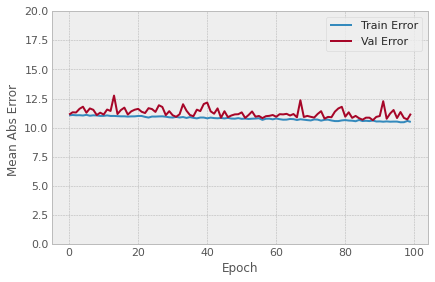

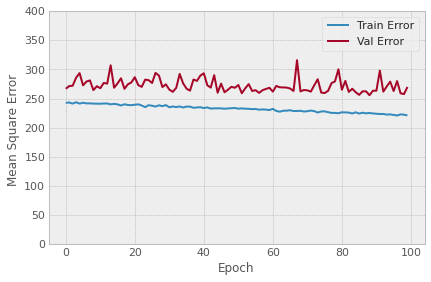

In [ ]:
plot_history(history)

In [ ]:
# The patience parameter is the amount of epochs to check for improvement
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

In [ ]:
history =  Keras_model.fit(X_train, y_train, epochs=EPOCHS,
                    validation_split = 0.2, verbose=0, callbacks=[early_stop])

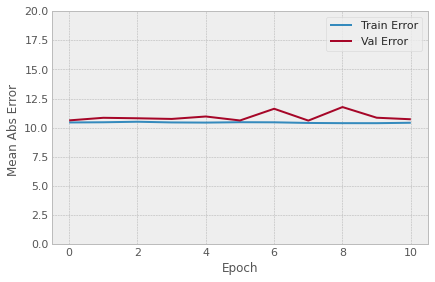

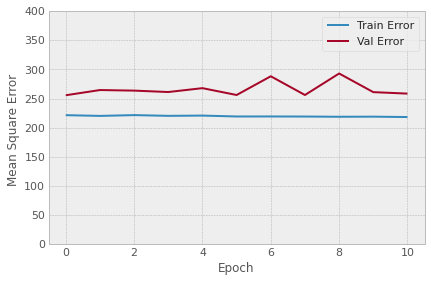

In [ ]:
plot_history(history)

In [ ]:
loss, mae, mse =  Keras_model.evaluate(X_test, y_test, verbose=0)
print("Testing set Mean Abs Error: {:5.2f} ".format(mae))
print("Testing set loss: {:5.2f} ".format(loss))
print("Testing set Mean squared Error: {:5.2f} ".format(mse))

Testing set Mean Abs Error: 11.80 
Testing set loss: 308.85 
Testing set Mean squared Error: 308.85 


In [ ]:
Keras_model.save('kerasRegression.model')
new_model = tf.keras.models.load_model('kerasRegression.model')
predictions = new_model.predict(X_test)
print(predictions)


[[155.0969 ]
 [151.88861]
 [195.57834]
 ...
 [199.06845]
 [119.57034]
 [192.15996]]


In [ ]:
y_pred =  Keras_model.predict(X_test).flatten()

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])

# Fixing the error: Removed plt.fig() and added ax.plot in the next cell which has a figure and axes created.
# The intention was likely to plot a diagonal line for perfect prediction, which is done in the next cell.

NameError: name 'y_test' is not defined

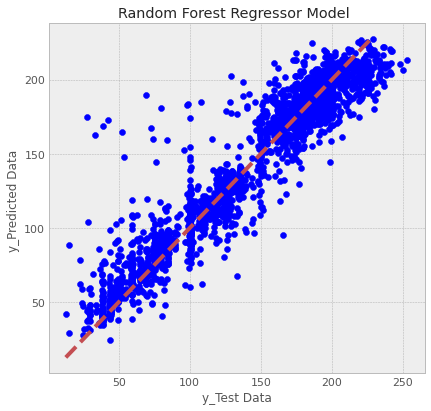

In [ ]:
fig = plt.figure(figsize=(6,6))
ax = plt.axes()
plt.scatter(y_test,y_pred,c="blue", label="All - Filtered")
ax.set(xlabel="y_Test Data", ylabel="y_Predicted Data ", title="Random Forest Regressor Model ")
ax.plot([y_test.min(), y_pred.max()], [y_test.min(),
y_pred.max()], 'r--', lw=4)
plt.show()

In [ ]:


#Calculating Mean Absolute Error
MAEValue_Keras_Model = mean_absolute_error(y_test, y_pred, multioutput='uniform_average') # it can be raw_values
print('Mean Absolute Error Value is : ', MAEValue_MLP)

Mean Absolute Error Value is :  11.080090668770524


In [ ]:
models = pd.DataFrame({
'Model': ['Linear Regression Model ', 'SGD Model ', 'Lassio Model',
'Random Forest Regressor ', 'Linear SVR',
'MLP Model '],
'Score':np.round(np.multiply(100,[score_LRM, score_SGD, score_LAS,
score_RFR, score_SVR, score_MLP]),0),
'Mean Absolute Error Value':[MAEValue_LRM,MAEValue_SGD,MAEValue_LAS,MAEValue_RFR,MAEValue_SVR,MAEValue_MLP]})
models.sort_values(by="Score", ascending=True)

models.set_index(["Model"], inplace = True,
append = False, drop = True)
models

,Score,Mean Absolute Error Value
Model,,
Linear Regression Model,75.0,21.031184
SGD Model,75.0,21.037472
Lassio Model,75.0,21.032588
Random Forest Regressor,93.0,8.396253
Linear SVR,87.0,12.884145
MLP Model,90.0,11.080091


In [ ]:
np.round(np.multiply(100,[score_LRM, score_SGD, score_LAS,
score_RFR, score_SVR, score_MLP]),0)

array([75., 75., 75., 93., 87., 90.])

from the above table , we can find that the best results come from Random Forest Regressor  

In [ ]:
#Applying Random Forest Regressor Model

'''
sklearn.ensemble.RandomForestRegressor(n_estimators='warn', criterion=’mse’, max_depth=None,
                                       min_samples_split=2, min_samples_leaf=1,min_weight_fraction_leaf=0.0,
                                       max_features=’auto’, max_leaf_nodes=None,min_impurity_decrease=0.0,
                                       min_impurity_split=None, bootstrap=True,oob_score=False, n_jobs=None,
                                       random_state=None, verbose=0,warm_start=False)
'''

RandomForestRegressorModel = RandomForestRegressor(n_estimators=1000,max_depth=10, random_state=33)
RandomForestRegressorModel.fit(X_train, y_train)

#Calculating Details
print('Random Forest Regressor Train Score is : ' , RandomForestRegressorModel.score(X_train, y_train))
print('Random Forest Regressor Test Score is : ' , RandomForestRegressorModel.score(X_test, y_test))
#print('Random Forest Regressor No. of features are : ' , RandomForestRegressorModel.n_features_)
#print('----------------------------------------------------')
score_RFR=RandomForestRegressorModel.score(X_test, y_test)
#Calculating Prediction
y_pred = RandomForestRegressorModel.predict(X_test)
#print('Predicted Value for Random Forest Regressor is : ' , y_pred[:10])

#Calculating Mean Absolute Error

MAEValue_RFR = mean_absolute_error(y_test, y_pred, multioutput='uniform_average') # it can be raw_values

#print('Mean Absolute Error Value is : ', MAEValue_RFR)


Random Forest Regressor Train Score is :  0.9700253936679842
Random Forest Regressor Test Score is :  0.9160735782221573


to get the most important features

In [ ]:
features_names=data.columns[:-1]
features_names

Index(['Hole Depth', 'Hook Load', 'Rotary RPM', 'Rotary Torque',
       'Weight on Bit', 'Differential Pressure', 'Gamma at Bit'],
      dtype='object')

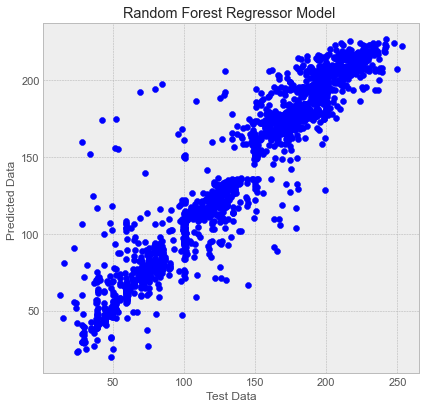

In [ ]:
plt.style.use('bmh')
#plt.style.use('classic')
fig = plt.figure(figsize=(6,6))
ax = plt.axes()
plt.scatter(y_test,y_pred,c="blue", label="All - Filtered")
ax.set(xlabel="Test Data", ylabel="Predicted Data ", title="Random Forest Regressor Model ")

plt.show()

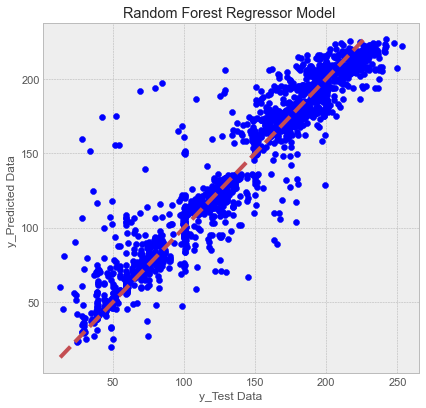

In [ ]:
plt.style.use('bmh')
#plt.style.use('classic')
fig = plt.figure(figsize=(6,6))
ax = plt.axes()
plt.scatter(y_test,y_pred,c="blue", label="All - Filtered")
ax.set(xlabel="y_Test Data", ylabel="y_Predicted Data ", title="Random Forest Regressor Model ")
ax.plot([y_test.min(), y_pred.max()], [y_test.min(),
y_pred.max()], 'r--', lw=4)
plt.show()


,0
Rotary Torque,0.656522
Rotary RPM,0.133616
Weight on Bit,0.089206
Hole Depth,0.050632
Differential Pressure,0.030086
Gamma at Bit,0.028923
Hook Load,0.011015


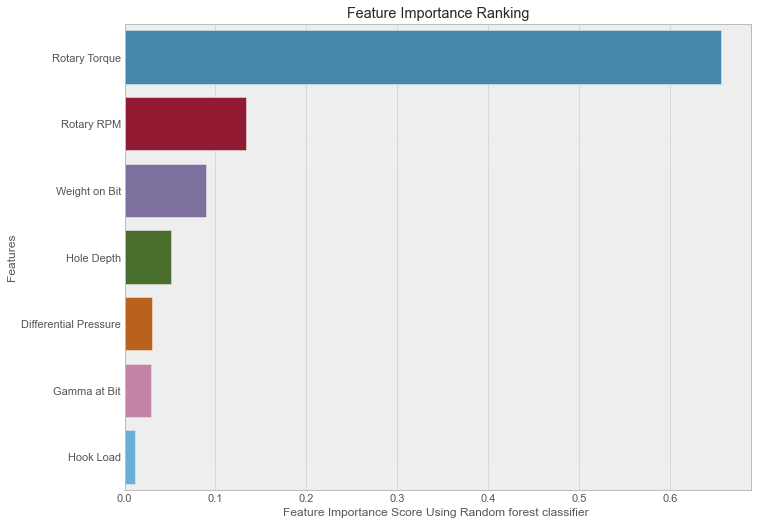

In [ ]:
fi_RFR= RandomForestRegressorModel.feature_importances_

plt.figure(figsize=(10,8))
feature_imp =pd.Series(fi_RFR,index=features_names).sort_values(ascending=False)
feature_imp


sns.barplot(x=feature_imp, y=feature_imp.index)
plt.xlabel('Feature Importance Score Using Random forest classifier ')
plt.ylabel('Features')
plt.title("Feature Importance Ranking")

feature_imp=pd.DataFrame(feature_imp)
feature_imp

D:\python\New folder\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
D:\python\New folder\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Rotary Torque', ylabel='Hole Depth'>

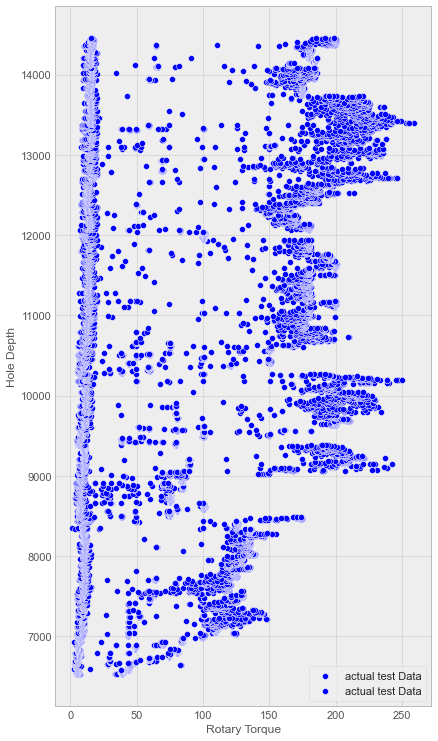

In [ ]:
plt.figure(figsize=(6,12))
sns.scatterplot(y, data['Hole Depth'],
label='actual test Data', color='blue')
sns.scatterplot(data["Rotary Torque"], data['Hole Depth'],
label='actual test Data', color='blue')

In [ ]:
data.columns

Index(['Hole Depth', 'Hook Load', 'Rotary RPM', 'Rotary Torque',
       'Weight on Bit', 'Differential Pressure', 'Gamma at Bit',
       'Rate Of Penetration'],
      dtype='object')

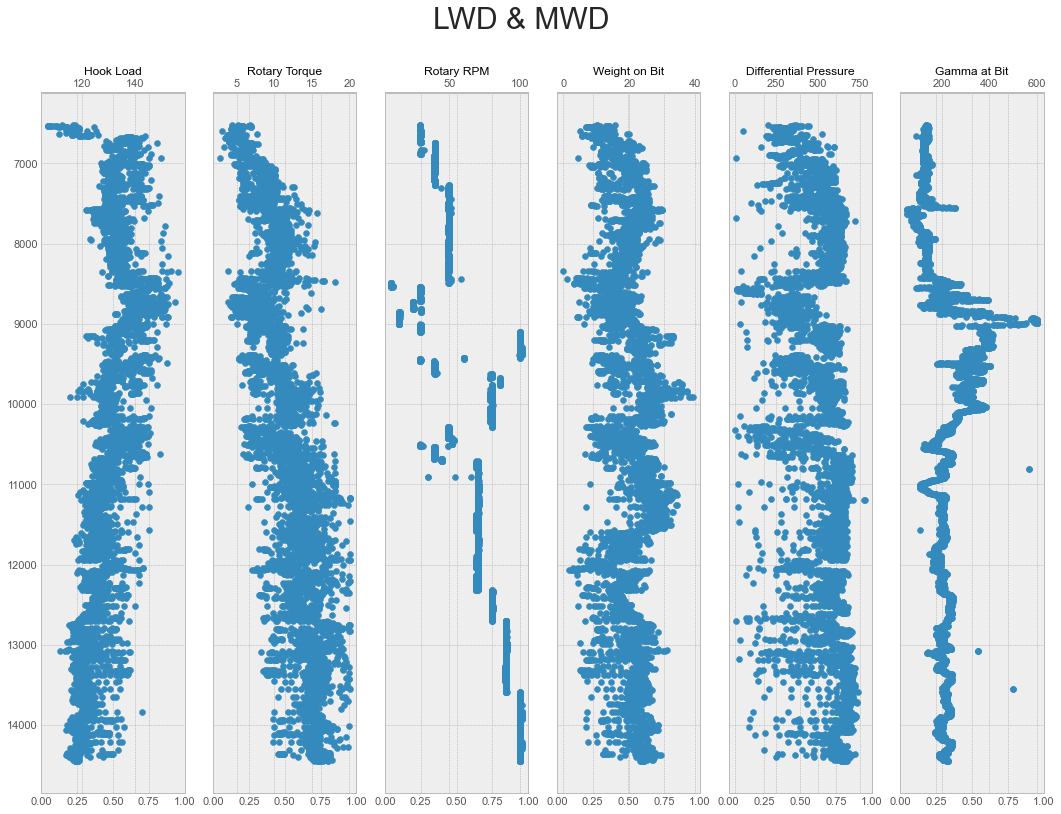

In [ ]:
fig,ax= plt.subplots(nrows=1, ncols=6,figsize=(16,12),sharey=True)
fig.suptitle("LWD & MWD ", fontsize=30)

# Track #1:

ax1=ax[0].twiny()
#ax1.invert_yaxis()
ax1.scatter(data["Hook Load"],data["Hole Depth"])
ax1.set_xlabel('Hook Load',color='black')
ax1.tick_params(axis='x', color='black')
ax1.spines['top'].set_position(('outward',1))


ax1=ax[1].twiny()
#ax1.invert_yaxis()
ax1.scatter(data["Rotary Torque"],data["Hole Depth"])
ax1.set_xlabel('Rotary Torque',color='black')
ax1.tick_params(axis='x', color='black')
ax1.spines['top'].set_position(('outward',1))



ax1=ax[2].twiny()
#ax1.invert_yaxis()
ax1.scatter(data["Rotary RPM"],data["Hole Depth"])
ax1.set_xlabel('Rotary RPM',color='black')
ax1.tick_params(axis='x', color='black')
ax1.spines['top'].set_position(('outward',1))


ax1=ax[3].twiny()
#ax1.invert_yaxis()
ax1.scatter(data["Weight on Bit"],data["Hole Depth"])
ax1.set_xlabel('Weight on Bit',color='black')
ax1.tick_params(axis='x', color='black')
ax1.spines['top'].set_position(('outward',1))




ax1=ax[4].twiny()
#ax1.invert_yaxis()
ax1.scatter(data["Differential Pressure"],data["Hole Depth"])
ax1.set_xlabel('Differential Pressure',color='black')
ax1.tick_params(axis='x', color='black')
ax1.spines['top'].set_position(('outward',1))


ax1=ax[5].twiny()
#ax1.invert_yaxis()
ax1.scatter(data["Gamma at Bit"],data["Hole Depth"])
ax1.set_xlabel('Gamma at Bit',color='black')
#ax1.tick_params(axis='x', color='black')
ax1.spines['top'].set_position(('outward',1))

plt.gca().invert_yaxis()


D:\python\New folder\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
D:\python\New folder\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Rotary Torque', ylabel='Hole Depth'>

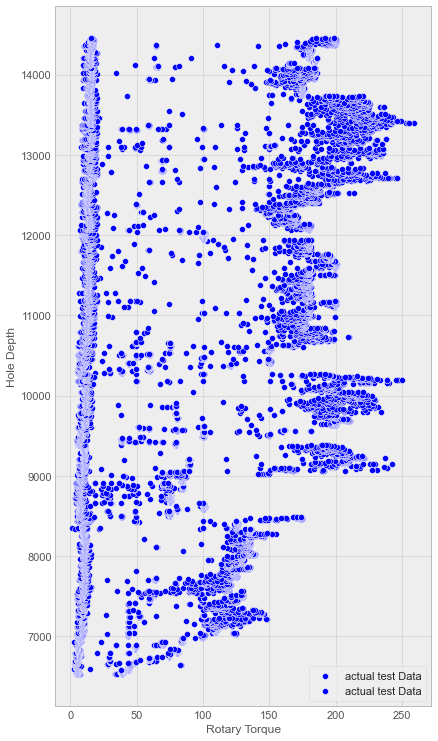

In [ ]:
#plt.gca().invert_yaxis()

plt.figure(figsize=(6,12))
sns.scatterplot(y, data['Hole Depth'],
label='actual test Data', color='blue')
sns.scatterplot(data["Rotary Torque"], data['Hole Depth'],
label='actual test Data', color='blue')